<br>
<div style="text-align:center;">
    <span style="color:#99BBF4; font-size:33px; font-weight:bold;">
       NOTEBOOK 2 v1.0. MODELO RANDOM FOREST DE VARIABLES ACÚSTICAS CON VALIDACIÓN PARA CLASIFICACIÓN ALS VS HC
    </span>
</div>

<div style="text-align:center;">
    <span style="color:#6593BA; font-size:22px; font-weight:bold;">
        Trabajo Fin de Grado
    </span>
    <br>
    <span style="color:#6593BA; font-size:20px; font-weight:bold;">
        Ingeniería Biomédica Curso 2025/2026
    </span>
</div>
<br>

<br>
<div style="text-align:left;">
    <span style="color:#4F75B6; font-size:25px; font-weight:bold;">
        ÍNDICE
    </span>

<div style="text-align:LEFT;">
    <span style="color:#99BBF4; font-size:20px; font-weight:bold;">
       INTRODUCCIÓN
    </span>
</div>

<span style="color:#6593BA; font-size:20px; font-weight:bold; font-family: Calibri;">
        1. Introducción y objetivos del experimento
        <br>
        2. Configuración técnica y variables globales
        <br>
</span>

<div style="text-align:LEFT;">
    <span style="color:#99BBF4; font-size:20px; font-weight:bold;">
       BLOQUE 1. PREPARACIÓN DE DATOS Y DEFINICIÓN DEL PROBLEMA
    </span>
</div>

<span style="color:#6593BA; font-size:20px; font-weight:bold; font-family: Calibri;">
        3. Carga y verificación de los datos
        <br>
        4. Definición del problema supervisado
        <br>
        5. Estrategia de validación y control de fuga de información
        <br>
        6. Definición de conjuntos de features
        <br>
</span>

<div style="text-align:LEFT;">
    <span style="color:#99BBF4; font-size:20px; font-weight:bold;">
       BLOQUE 2. PIPELINE DE PREPROCESAMIENTO
    </span>
</div>

<span style="color:#6593BA; font-size:20px; font-weight:bold; font-family: Calibri;">
        7. Diseño del pipeline de preprocesamiento
        <br>
        8. Limpieza de columnas mal tipadas
        <br>
        9. Tratamiento de variables numéricas
        <br>
        10. Tratamiento de variables categóricas
        <br>
        11. Construcción del ColumnTransformer
        <br>
</span>

<div style="text-align:LEFT;">
    <span style="color:#99BBF4; font-size:20px; font-weight:bold;">
       BLOQUE 3. DEFINICIÓN DEL MODELO Y OPTIMIZACIÓN
    </span>
</div>

<span style="color:#6593BA; font-size:20px; font-weight:bold; font-family: Calibri;">
        12. Definición del modelo y estrategia de optimización
        <br>
        13. Feature Selection con SelectKBest
        <br>
        14. Grid Search de hiperparámetros
        <br>
        15. Construcción del Pipeline completo
        <br>
        16. Nested Cross-Validation
        <br>
        17. Entrenamiento del modelo final
        <br>
</span>

<div style="text-align:LEFT;">
    <span style="color:#99BBF4; font-size:20px; font-weight:bold;">
       BLOQUE 4. EVALUACIÓN DEL MODELO
    </span>
</div>

<span style="color:#6593BA; font-size:20px; font-weight:bold; font-family: Calibri;">
        18. Evaluación en Validation Set
        <br>
        19. Análisis FP/FN en Validation
        <br>
        20. Análisis de importancia de variables (Permutation Importance y MDI)
        <br>
        21. Evaluación final en Test Set
        <br>
        22. Análisis FP/FN en Test
        <br>
</span>

<div style="text-align:LEFT;">
    <span style="color:#99BBF4; font-size:20px; font-weight:bold;">
       BLOQUE 5. CALIBRACIÓN DE PROBABILIDADES
    </span>
</div>

<span style="color:#6593BA; font-size:20px; font-weight:bold; font-family: Calibri;">
        23. Entrenamiento de modelos calibrados
        <br>
        24. Curvas ROC — Validation vs Test
        <br>
        25. Curvas de calibración
        <br>
        26. Distribución de probabilidades
        <br>
</span>

<div style="text-align:LEFT;">
    <span style="color:#99BBF4; font-size:20px; font-weight:bold;">
       CONCLUSIONES
    </span>
</div>

<span style="color:#6593BA; font-size:20px; font-weight:bold; font-family: Calibri;">
        27. Resumen de las conclusiones finales
        <br>
</span>

#
---
#
<div style="text-align:left;">
    <span style="color:#4F75B6; font-size:25px; font-weight:bold;">
        INTRODUCCIÓN
    </span>

<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 1. Introducción y objetivos del experimento</span>
</div>

<div style="text-align:left;"> 
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;"> 
Este notebook desarrolla un modelo de <b>Random Forest</b> para clasificación binaria entre pacientes con Esclerosis Lateral Amiotrófica (ALS) y controles sanos (HC), aplicado sobre variables acústicas del habla extraídas del dataset VOC-ALS.
<br><br>
El punto de partida es una premisa clínica que propone que la ELA produce, en una proporción significativa de casos, afectación bulbar progresiva que compromete los mecanismos neuromusculares del habla. Esta alteración se manifiesta como disartria, una degradación de la articulación, la prosodia y la calidad vocal que puede ser capturada y cuantificada mediante análisis acústico. Variables como la frecuencia fundamental (F0), el HNR (<i>Harmonics-to-Noise Ratio</i>), el jitter y el shimmer reflejan directamente la estabilidad del control motor laríngeo y articulatorio, y constituyen por tanto parámetros cuantificables de la integridad del sistema nervioso motor.
    </span> 
</div>

<div style="text-align:left;color:#6593BA;"> 
    <span style="font-size:20px; font-family:Calibri; text-align:justify; display: inline-block;"> 
        <strong>Planteamiento del experimento</strong>
    </span>
</div>

<div style="text-align:left;"> 
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;"> 
El experimento se formula como un problema de clasificación supervisada binaria. La variable objetivo es <code>Category</code> ∈ {ALS, HC} y el conjunto de predictores utiliza las <b>50 variables acústicas</b> disponibles en el dataset, derivadas de cinco métricas (meanF0Hz, stdevF0Hz, HNR, localJitter, localShimmer) calculadas sobre diez tareas vocales diferentes:
<br>
<ul>
<li>Vocales sostenidas: A, E, I, O, U</li>
<li>Sílabas repetidas: PA, TA, KA</li>
<li>Lectura en voz alta (reading)</li>
<li>Habla espontánea sobre días laborables (weekdays)</li>
</ul>
Esta configuración permite evaluar de forma aislada la capacidad discriminativa de la señal vocal sin añadir complejidad innecesaria mediante variables demográficas o clínicas.
    </span> 
</div>

<div style="text-align:left;color:#6593BA;"> 
    <span style="font-size:20px; font-family:Calibri; text-align:justify; display: inline-block;"> 
        <strong>Mejoras metodológicas implementadas</strong>
    </span>
</div>

<div style="text-align:left;"> 
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;"> 
Este notebook incorpora ciertas mejoras sobre etapas iniciales del modelo, orientadas a controlar el overfitting y garantizar estimaciones conservadoras del rendimiento:
<br><br>
<ul>
<li><b>Nested Cross-Validation (5×3):</b> Estimación no sesgada del rendimiento mediante validación cruzada anidada. El loop externo (5 folds) evalúa el rendimiento, mientras que el loop interno (3 folds) optimiza hiperparámetros en cada fold externo de forma independiente.</li>
<li><b>Feature Selection integrada:</b> Reducción dimensional mediante <code>SelectKBest</code> con test ANOVA F, integrado en el pipeline. Esto permite evaluar diferentes configuraciones de número de features (k=10, 15, 20) sin introducir data leakage.</li>
<li><b>Grid Search exhaustivo:</b> Búsqueda sistemática de hiperparámetros mediante <code>GridSearchCV</code>. Se exploran 216 combinaciones de n_estimators, max_depth, min_samples_split, min_samples_leaf y class_weight para identificar la configuración óptima.</li>
<li><b>Permutation Importance:</b> Análisis de importancia de variables mediante permutación de features en el validation set. Este método no presenta los sesgos sistemáticos de MDI (Mean Decrease Impurity) hacia variables continuas o de alta cardinalidad.</li>
<li><b>MLflow Tracking:</b> Registro automático de todos los experimentos, métricas, hiperparámetros y artefactos mediante MLflow. Esto garantiza trazabilidad completa y reproducibilidad total del proceso.</li>
<li><b>Test Set Hold-out:</b> Evaluación final en conjunto completamente no visto hasta el momento de la evaluación definitiva. El test set nunca interviene en ninguna decisión de modelado.</li>
<li><b>Auditoría de Data Leakage:</b> Verificaciones automáticas de integridad del split por ID de sujeto, asegurando que ningún paciente aparezca simultáneamente en train, validation y test.</li>
</ul>
</span> 
</div>

<div style="text-align:left;color:#6593BA;"> 
    <span style="font-size:20px; font-family:Calibri; text-align:justify; display: inline-block;"> 
        <strong>Consideraciones metodológicas </strong>
    </span>
</div>

<div style="text-align:left;"> 
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;"> 
El diseño de los experimentos incorpora las siguientes decisiones técnicas:
<br><br>
<ul>
<li><b>Split por sujeto:</b> La partición Train/Validation/Test se realiza a nivel de paciente (ID), no de muestra. Esto es un punto fundamental en datasets clínicos pequeños puesto que, si un mismo sujeto apareciera en train y en validación, el modelo podría memorizar características propias del individuo en lugar de aprender patrones generalizables a la población. El fichero <code>subject_split.csv</code> garantiza esta separación, y el código verifica la ausencia de solapamiento entre los tres conjuntos.</li>
<br>
<li><b>Pipeline encapsulado:</b> Todas las transformaciones de preprocesamiento (imputación de valores ausentes, escalado de variables numéricas, feature selection) se integran dentro de un objeto <code>Pipeline</code> de scikit-learn. Esto asegura que el ajuste de estas transformaciones (cálculo de medianas, medias, rangos, selección de features) se realice exclusivamente sobre los datos de entrenamiento de cada fold. Aplicar, por ejemplo, una imputación global antes del split equivaldría a contaminar el proceso con información estadística de validación y test, inflando artificialmente las métricas.</li>
<br>
<li><b>Tratamiento de columnas con tipado mixto:</b> Varias columnas clínicas del dataset (<code>FVC%</code>, <code>DiagnosticDelay</code>, <code>DiseaseDuration</code>) presentan el valor <code>"-"</code> para los controles sanos, lo que provoca que pandas las infiera como tipo <code>object</code> en lugar de <code>float</code>. La solución adoptada es aplicar <code>pd.to_numeric(errors='coerce')</code> sobre estas columnas antes de la entrada al pipeline, transformando los strings no numéricos en <code>NaN</code>. El <code>SimpleImputer</code> del pipeline los imputa posteriormente con la mediana del conjunto de entrenamiento, sin comprometer la integridad del split.</li>
<br>
<li><b>Regularización del Random Forest:</b> Se aplican restricciones sobre los hiperparámetros del árbol para controlar el overfitting: <code>max_depth</code> limitado, <code>min_samples_split</code> y <code>min_samples_leaf</code> incrementados, y evaluación de <code>class_weight='balanced'</code> para manejar el desbalanceo de clases (67% ALS vs 33% HC).</li>
<br>
<li><b>Limitaciones del dataset:</b> El tamaño muestral (n=153, train≈107) es una restricción que limita el rendimiento alcanzable. El ratio original muestras/features es de apenas 2.14:1, muy por debajo del mínimo recomendado de 10:1. La feature selection con SelectKBest mitiga parcialmente este problema reduciendo la dimensionalidad a 10-20 features, elevando el ratio a ~5-7:1.</li>
</ul>
    </span> 
</div>

#
<br>
<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 2. Configuración técnica y variables globales</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
Se importan todas las librerías necesarias para el experimento y se fijan las rutas del dataset, el split y el directorio de resultados. La semilla global <code>SEED = 42</code> se aplica a NumPy, Python random y la variable de entorno <code>PYTHONHASHSEED</code> para garantizar la reproducibilidad total del experimento. Se configura también el experimento de MLflow bajo el que se registrarán todos los runs generados en este notebook.
    </span>
</div>

In [39]:
# CONFIGURACIÓN DEL ENTORNO
import os
import sys
import sys
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
import json

# Machine Learning
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.metrics import precision_recall_curve, average_precision_score, PrecisionRecallDisplay
from sklearn.metrics import roc_curve, roc_auc_score, auc 
from sklearn.calibration import CalibratedClassifierCV, calibration_curve 
from sklearn.metrics import brier_score_loss
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import (
    StratifiedKFold, GridSearchCV, cross_validate, cross_val_predict
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay, balanced_accuracy_score
)
from sklearn.inspection import permutation_importance

# MLflow para experiment tracking
import mlflow
import mlflow.sklearn

# Configuración de visualización
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# SEMILLA PARA REPRODUCIBILIDAD 
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

print("Librerías importadas correctamente")
print(f"  Python:       {sys.version.split()[0]}")
print(f"  NumPy:        {np.__version__}")
print(f"  Pandas:       {pd.__version__}")
print(f"  Scikit-learn: {__import__('sklearn').__version__}")
print(f"  MLflow:       {mlflow.__version__}")

Librerías importadas correctamente
  Python:       3.13.0
  NumPy:        2.4.2
  Pandas:       2.3.3
  Scikit-learn: 1.8.0
  MLflow:       3.10.0


In [40]:
# VARIABLES GLOBALES Y RUTAS
DATASET_PATH = r"C:\Users\Laura\OneDrive\TFG\artifacts\metadata\VOC-ALS.xlsx"
SPLIT_PATH = r"C:\Users\Laura\OneDrive\TFG\artifacts\splits\subject_split.csv"
RESULTS_PATH = Path(r"C:\Users\Laura\OneDrive\TFG\results\02_model_random_forest_v1.0")
#RESULTS_PATH.mkdir(exist_ok=True)

SHEET_NAME = "VOC-ALS_Data"
TARGET = "Category"  # ALS/HC
ID_COL = "ID"

# Configuración MLflow
MLFLOW_EXPERIMENT_NAME = "Random_Forest_ALS_Classification"
mlflow.set_experiment(MLFLOW_EXPERIMENT_NAME)

print(f"Configuración cargada")
print(f"  Dataset: {DATASET_PATH}")
print(f"  Split:   {SPLIT_PATH}")
print(f"  Results: {RESULTS_PATH}")
print(f"  MLflow experiment: {MLFLOW_EXPERIMENT_NAME}")

Configuración cargada
  Dataset: C:\Users\Laura\OneDrive\TFG\artifacts\metadata\VOC-ALS.xlsx
  Split:   C:\Users\Laura\OneDrive\TFG\artifacts\splits\subject_split.csv
  Results: C:\Users\Laura\OneDrive\TFG\results\02_model_random_forest_v1.0
  MLflow experiment: Random_Forest_ALS_Classification


#
---
#
<div style="text-align:left;">
    <span style="color:#4F75B6; font-size:25px; font-weight:bold;">BLOQUE 1. PREPARACIÓN DE DATOS Y DEFINICIÓN DEL PROBLEMA</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
Este bloque establece la infraestructura de datos sobre la que se construye el experimento. Comprende la carga del dataset VOC-ALS, la definición del problema de clasificación supervisada, la estrategia de particionado sin fuga de información y la especificación del espacio de features acústicas. Estas operaciones, aunque técnicamente previas al modelado, son metodológicamente fundamentales: cualquier decisión incorrecta en esta fase (una partición que permita solapamiento de sujetos entre conjuntos, unas features mal construidas o un target mal codificado) invalida la totalidad de los resultados posteriores.
    </span>
</div>

#
<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 3. Carga y verificación de los datos</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
Se carga el archivo Excel <code>VOC-ALS.xlsx</code> (hoja <code>VOC-ALS_Data</code>, cabecera en la fila 1) y el archivo de split <code>subject_split.csv</code>. Tras la carga se verifican las dimensiones del dataset (153 filas × 89 columnas), los tipos de datos de cada columna y la distribución de la variable objetivo: 102 sujetos ALS (66.7%) y 51 HC (33.3%). Este desbalance de 2:1 tendrá implicaciones en la configuración del modelo, especialmente en la métrica de evaluación principal (balanced accuracy en lugar de accuracy simple) y en el parámetro <code>class_weight</code>.
    </span>
</div>

In [41]:
# Carga de los datos
if not os.path.exists(DATASET_PATH):
    raise FileNotFoundError(f"No se encuentra el archivo: {DATASET_PATH}")

df = pd.read_excel(DATASET_PATH, SHEET_NAME, header=1)
split_df = pd.read_csv(SPLIT_PATH)

print(f"Dataset cargado: {df.shape[0]} filas × {df.shape[1]} columnas")
print(f"Split cargado:   {split_df.shape[0]} sujetos")

# Verificación de la estructura
print("\nTipos de datos:")
display(df.dtypes)

print("\nPrimeras filas:")
display(df.head())

print("\nDistribución de la variable objetivo:")
display(df[TARGET].value_counts())
display((df[TARGET].value_counts(normalize=True) * 100).round(2))

Dataset cargado: 153 filas × 89 columnas
Split cargado:   153 sujetos

Tipos de datos:


ID                           object
Age (years)                   int64
Sex                          object
Category                     object
OnsetRegion                  object
                             ...   
stdevF0Hz_weekdays          float64
HNR_weekdays                float64
localJitter_weekdays        float64
localShimmer_weekdays       float64
Cantagallo_Questionnaire      int64
Length: 89, dtype: object


Primeras filas:


,ID,Age (years),Sex,Category,OnsetRegion,Therapy,GeneticTest,DiagnosticDelay,DiseaseDuration,FVC%,...,stdevF0Hz_reading,HNR_reading,localJitter_reading,localShimmer_reading,meanF0Hz_weekdays,stdevF0Hz_weekdays,HNR_weekdays,localJitter_weekdays,localShimmer_weekdays,Cantagallo_Questionnaire
0,CT001,56,F,HC,-,-,-,-,-,-,...,33.375746,13.675099,0.023379,0.113960,167.768436,15.147806,14.020984,0.017668,0.112806,7
1,CT004,72,F,HC,-,-,-,-,-,-,...,24.607553,20.211916,0.013030,0.068701,195.725146,25.969098,19.756000,0.011523,0.059758,0
2,CT010,60,F,HC,-,-,-,-,-,-,...,22.178551,14.987857,0.018725,0.083444,129.716457,13.611625,15.968968,0.022525,0.084763,22
3,CT013,64,F,HC,-,-,-,-,-,-,...,40.830735,13.950918,0.023394,0.114586,196.566747,15.810296,14.328929,0.026948,0.122271,12
4,CT014,62,F,HC,-,-,-,-,-,-,...,36.952328,14.039653,0.026335,0.103564,184.407533,30.296640,13.525610,0.028864,0.123836,3



Distribución de la variable objetivo:


Category
ALS    102
HC      51
Name: count, dtype: int64

Category
ALS    66.67
HC     33.33
Name: proportion, dtype: float64

#
<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 4. Definición del problema supervisado</span>
</div>

<div style="text-align:left;"> 
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;"> 
Se define el problema de clasificación supervisada mediante la separación de features (X) y target (y). La columna <code>Category</code> contiene las etiquetas binarias ALS/HC que se codificarán posteriormente mediante <code>LabelEncoder</code> para compatibilidad con scikit-learn. La columna <code>ID</code> se excluye del conjunto de features por ser un identificador sin valor predictivo.
    </span> 
</div>

In [42]:
# Separación de features y target
X = df.drop(columns=[TARGET, ID_COL])
y = df[TARGET]

print(f"X (features): {X.shape}")
print(f"y (target):   {y.shape}")
print(f"\nClases únicas en y: {y.unique()}")

X (features): (153, 87)
y (target):   (153,)

Clases únicas en y: ['HC' 'ALS']


#
<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 5. Estrategia de validación y control de fuga de información</span>
</div>

<div style="text-align:left;"> 
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;"> 
El split Train/Validation/Test se carga desde el archivo <code>subject_split.csv</code>, que contiene la asignación de cada ID de sujeto a uno de los tres conjuntos. Esta partición se realizó previamente de forma estratificada por clase (ALS/HC) para mantener la distribución 67%-33% en cada conjunto.
<br><br>
Es importante destacar que la partición se realiza <u>a nivel de sujeto</u>, no de muestra. Esto permite que todas las observaciones de un mismo paciente permanecen juntas en el mismo conjunto, evitando que el modelo memorice características individuales en lugar de aprender patrones generalizables.
<br><br>
El código incluye <b>verificaciones automáticas</b> para asegurar la ausencia de solapamiento entre conjuntos:
<ul>
<li>Ningún ID aparece simultáneamente en train, validation y test</li>
<li>La suma de los tres conjuntos recupera el total de sujetos</li>
<li>La distribución de clases se mantiene aproximadamente constante en los tres splits</li>
</ul>
    </span> 
</div>

In [43]:
# Carga del split pre-generado
train_ids = split_df[split_df['Split'] == 'Train'][ID_COL].values
val_ids   = split_df[split_df['Split'] == 'Validation'][ID_COL].values
test_ids  = split_df[split_df['Split'] == 'Test'][ID_COL].values

print(f"IDs en train:      {len(train_ids)}")
print(f"IDs en validation: {len(val_ids)}")
print(f"IDs en test:       {len(test_ids)}")
print(f"Total:             {len(train_ids) + len(val_ids) + len(test_ids)}")

# Verificación de ausencia de solapamiento entre conjuntos
assert len(set(train_ids) & set(val_ids)) == 0, "LEAK: train ∩ validation != ∅"
assert len(set(train_ids) & set(test_ids)) == 0, "LEAK: train ∩ test != ∅"
assert len(set(val_ids) & set(test_ids)) == 0,   "LEAK: validation ∩ test != ∅"
print("\nVerificación del split: Sin presencia de solapamiento")

# Construcción de los splits
train_mask = df[ID_COL].isin(train_ids)
val_mask   = df[ID_COL].isin(val_ids)
test_mask  = df[ID_COL].isin(test_ids)

X_train, y_train = X[train_mask], y[train_mask]
X_val,   y_val   = X[val_mask],   y[val_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

print(f"\nTrain set:      {X_train.shape[0]} muestras")
print(f"Validation set: {X_val.shape[0]} muestras")
print(f"Test set:       {X_test.shape[0]} muestras")

# Distribución de clases en cada conjunto
print("\nDistribución de clases:")
print(f"  Train:      {y_train.value_counts().to_dict()}")
print(f"  Validation: {y_val.value_counts().to_dict()}")
print(f"  Test:       {y_test.value_counts().to_dict()}")

IDs en train:      107
IDs en validation: 23
IDs en test:       23
Total:             153

Verificación del split: Sin presencia de solapamiento

Train set:      107 muestras
Validation set: 23 muestras
Test set:       23 muestras

Distribución de clases:
  Train:      {'ALS': 71, 'HC': 36}
  Validation: {'ALS': 15, 'HC': 8}
  Test:       {'ALS': 16, 'HC': 7}


#
<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 6. Definición de conjuntos de features</span>
</div>

<div style="text-align:left;"> 
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;"> 
Se definen los conjuntos de variables acústicas que alimentarán el modelo. Las <code>ACOUSTIC_COLS</code> se construyen mediante el producto cartesiano de 5 métricas acústicas × 10 tareas vocales, generando las 50 variables acústicas disponibles.
<br><br>
Adicionalmente, se identifican las columnas con tipado mixto (<code>PROBLEMATIC_COLS</code>) que requieren conversión a numérico antes de entrar al pipeline, dado que contienen el valor <code>"-"</code> como string en los sujetos HC.
    </span> 
</div>

In [44]:
# Columnas problemáticas (tipado mixto str/float con '-' en HC)
PROBLEMATIC_COLS = ["FVC%", "DiagnosticDelay", "DiseaseDuration"]

# VARIABLES ACÚSTICAS
# Prefijos acústicos × tareas vocales
_acoustic_prefixes = ["meanF0Hz", "stdevF0Hz", "HNR", "localJitter", "localShimmer"]
_acoustic_tasks    = ["A", "E", "I", "O", "U", "PA", "TA", "KA", "reading", "weekdays"]

ACOUSTIC_COLS = [
    f"{prefix}_{task}"
    for prefix in _acoustic_prefixes
    for task   in _acoustic_tasks
    if f"{prefix}_{task}" in X.columns   # solo las que existan en el dataset
]

# Summary
print(f"Variables acústicas:    {len(ACOUSTIC_COLS)}")
print(f"Columnas problemáticas: {PROBLEMATIC_COLS}")
print(f"\nEjemplos de variables acústicas:")
for col in ACOUSTIC_COLS[:10]:
    print(f"  - {col}")
print("  ...")

Variables acústicas:    50
Columnas problemáticas: ['FVC%', 'DiagnosticDelay', 'DiseaseDuration']

Ejemplos de variables acústicas:
  - meanF0Hz_A
  - meanF0Hz_E
  - meanF0Hz_I
  - meanF0Hz_O
  - meanF0Hz_U
  - meanF0Hz_PA
  - meanF0Hz_TA
  - meanF0Hz_KA
  - meanF0Hz_reading
  - meanF0Hz_weekdays
  ...


#
---
#
<div style="text-align:left;">
    <span style="color:#4F75B6; font-size:25px; font-weight:bold;">BLOQUE 2. PIPELINE DE PREPROCESAMIENTO</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
El pipeline de preprocesamiento encapsula todas las transformaciones necesarias antes del entrenamiento en una única estructura de scikit-learn. Este diseño es una garantía metodológica: el ajuste de cualquier transformación (cálculo de medianas para imputación, parámetros de escalado, selección de features) ocurre exclusivamente sobre los datos de entrenamiento de cada fold, nunca sobre validación ni test. Cualquier transformación ajustada fuera del pipeline (por ejemplo, una imputación global antes del split) contaminaría el proceso con información estadística de los conjuntos de evaluación, inflando artificialmente las métricas.
    </span>
</div>

#
<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 7. Diseño del pipeline de preprocesamiento</span>
</div>

<div style="text-align:left;"> 
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;"> 
El pipeline de preprocesamiento se construye mediante los objetos <code>Pipeline</code> y <code>ColumnTransformer</code> de scikit-learn, encapsulando en una única estructura todas las transformaciones necesarias antes del entrenamiento. Este diseño garantiza que ninguna transformación se ajuste sobre datos de validación o test, y permite aplicar el preprocesamiento de forma reproducible en cualquier partición.
<br><br>
El tratamiento difiere según la naturaleza de cada variable. Las <b>variables numéricas</b> se procesan mediante un sub-pipeline compuesto por dos etapas secuenciales: imputación de valores ausentes con la mediana del conjunto de entrenamiento, mediante <code>SimpleImputer(strategy="median")</code>, seguida de estandarización con <code>StandardScaler</code>. Se hace uso de la mediana frente a la media como estadístico de imputación debido a su mayor estabilidad frente a valores atípicos, frecuentes en variables acústicas y clínicas.
<br><br>
Previamente a la entrada al pipeline, las columnas con tipado mixto identificadas en el apartado anterior se someten a una conversión mediante <code>pd.to_numeric(errors="coerce")</code>, que transforma los strings no numéricos en <code>NaN</code> para que el <code>SimpleImputer</code> los trate correctamente. Esta conversión se aplica de forma igualitaria sobre los tres splits.
    </span> 
</div>

#
<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 8. Limpieza de columnas mal tipadas</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
Las columnas <code>FVC%</code>, <code>DiagnosticDelay</code> y <code>DiseaseDuration</code> presentan el valor <code>"-"</code> como string en los sujetos HC (para quienes estas variables clínicas no aplican). Pandas las infiere por tanto como tipo <code>object</code>. Antes de que entren al pipeline, se aplica <code>pd.to_numeric(errors="coerce")</code> sobre estas columnas en los tres splits por separado, convirtiendo los strings no numéricos en <code>NaN</code>. El <code>SimpleImputer</code> del pipeline los tratará posteriormente con la mediana del conjunto de entrenamiento, sin comprometer la integridad de la partición.
    </span>
</div>

In [45]:
def force_numeric_columns(df: pd.DataFrame, cols: list) -> pd.DataFrame:
    """Fuerza la conversión a numérico de columnas con tipado mixto.
    
    Aplica pd.to_numeric(errors='coerce') sobre cada columna especificada,
    transformando los valores no convertibles (p.ej. '-') en NaN. Los NaN
    resultantes serán imputados posteriormente por el SimpleImputer del pipeline
    usando la mediana del conjunto de entrenamiento.
    
    Args:
        df (pd.DataFrame): DataFrame de entrada. No se modifica el original.
        cols (list): Lista de nombres de columnas a convertir.
    
    Returns:
        pd.DataFrame: Copia del DataFrame con las columnas especificadas
            convertidas a dtype float64.
    """
    df = df.copy()
    for col in cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    return df


# Aplicamos sobre los tres splits
X_train_clean = force_numeric_columns(X_train, PROBLEMATIC_COLS)
X_val_clean   = force_numeric_columns(X_val,   PROBLEMATIC_COLS)
X_test_clean  = force_numeric_columns(X_test,  PROBLEMATIC_COLS)

# Verificación de dtype y NaN generados por columna
print("Conversión de columnas problemáticas:")
for col in PROBLEMATIC_COLS:
    if col in X_train_clean.columns:
        n_nan = X_train_clean[col].isna().sum()
        print(f"  {col:25s}  dtype: {X_train_clean[col].dtype}  |  NaN: {n_nan}/{len(X_train_clean)}")

Conversión de columnas problemáticas:
  DiagnosticDelay            dtype: float64  |  NaN: 36/107
  DiseaseDuration            dtype: float64  |  NaN: 36/107


#
<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 9. Tratamiento de variables numéricas</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
Las 50 variables acústicas son numéricas continuas y se procesan mediante un sub-pipeline de dos etapas secuenciales: imputación con <code>SimpleImputer(strategy="median")</code> seguida de estandarización con <code>StandardScaler</code>. Se usa la mediana en lugar de la media como estadístico de imputación por su mayor robustez frente a valores atípicos, frecuentes en variables acústicas y clínicas. El escalado es necesario porque, aunque el Random Forest es intrínsecamente invariante a la escala, la etapa de <code>SelectKBest</code> usa el test ANOVA F, cuyo estadístico no depende de la escala pero sí puede verse afectado por distribuciones muy asimétricas; el escalado previo estabiliza el proceso de selección.
    </span>
</div>

In [46]:
# Pipeline para variables numéricas: Imputación + Escalado
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

print("Pipeline numérico definido:")
print("  1. SimpleImputer(strategy='median')")
print("  2. StandardScaler()")

Pipeline numérico definido:
  1. SimpleImputer(strategy='median')
  2. StandardScaler()


#
<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 10. Tratamiento de variables categóricas</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
En el espacio de las 50 features acústicas no existen variables categóricas (todas son continuas). Sin embargo, el pipeline categórico se define igualmente como parte de la arquitectura genérica del <code>ColumnTransformer</code>, de modo que cualquier extensión futura del espacio de features que incluya variables categóricas quede cubierta sin necesidad de modificar el pipeline. El sub-pipeline aplica imputación por moda seguida de <code>OneHotEncoder</code> con manejo de categorías desconocidas.
    </span>
</div>

In [47]:
# Pipeline para variables categóricas: Imputación + One-Hot Encoding
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

print("Pipeline categórico definido:")
print("  1. SimpleImputer(strategy='most_frequent')")
print("  2. OneHotEncoder(handle_unknown='ignore')")

Pipeline categórico definido:
  1. SimpleImputer(strategy='most_frequent')
  2. OneHotEncoder(handle_unknown='ignore')


#
<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 11. Construcción del ColumnTransformer</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
El <code>ColumnTransformer</code> integra los dos sub-pipelines anteriores, aplicando cada uno al subconjunto de columnas correspondiente. El parámetro <code>remainder="drop"</code> descarta explícitamente cualquier columna no especificada en los transformadores, evitando que variables no deseadas (como identificadores o variables clínicas no relevantes) entren al modelo por descuido. La verificación de tipos confirma que las 50 columnas acústicas son numéricas, por lo que la rama categórica opera sobre un conjunto vacío en este experimento.
    </span>
</div>

In [48]:
# Identificación de columnas numéricas y categóricas en el conjunto de features acústicas
numeric_cols = [col for col in ACOUSTIC_COLS if X_train_clean[col].dtype in ['int64', 'float64']]
categorical_cols = [col for col in ACOUSTIC_COLS if X_train_clean[col].dtype == 'object']

print(f"Columnas numéricas:    {len(numeric_cols)}")
print(f"Columnas categóricas:  {len(categorical_cols)}")

# ColumnTransformer: aplica pipelines específicos a cada tipo de columna
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipeline,     numeric_cols),
        ('cat', categorical_pipeline, categorical_cols)
    ],
    remainder='drop'  # descarta columnas no especificadas
)

print("\nColumnTransformer construido")
print("  - Transforma variables numéricas y categóricas")
print("  - Descarta el resto de columnas (remainder='drop')")

Columnas numéricas:    50
Columnas categóricas:  0

ColumnTransformer construido
  - Transforma variables numéricas y categóricas
  - Descarta el resto de columnas (remainder='drop')


#
---
#
<div style="text-align:left;">
    <span style="color:#4F75B6; font-size:25px; font-weight:bold;">BLOQUE 3. DEFINICIÓN DEL MODELO Y OPTIMIZACIÓN</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
Este bloque construye el núcleo del experimento: el pipeline completo de clasificación, la búsqueda de hiperparámetros y la estimación no sesgada del rendimiento mediante nested cross-validation. Las decisiones de diseño adoptadas aquí (tipo de modelo, espacio de búsqueda, esquema de validación) son las que determinan la calidad metodológica del experimento y la fiabilidad de las métricas reportadas.
    </span>
</div>

#
<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 12. Definición del modelo y estrategia de optimización</span>
</div>


<div style="text-align:left;"> 
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;"> 
El modelo base es un <code>RandomForestClassifier</code> de scikit-learn, configurado con parámetros conservadores orientados a controlar el overfitting. Se integra dentro de un pipeline completo que incluye:
<br>
<ol>
<li><b>Preprocesamiento</b> (ColumnTransformer): Imputación y escalado de variables</li>
<li><b>Feature Selection</b> (SelectKBest): Reducción dimensional mediante test ANOVA F</li>
<li><b>Clasificador</b> (RandomForestClassifier): Ensemble de árboles de decisión</li>
</ol>
<br>
La optimización de hiperparámetros se realiza mediante <code>GridSearchCV</code>, revisando 216 combinaciones de:
<ul>
<li><code>k</code> (SelectKBest): número de features a seleccionar [10, 15, 20]</li>
<li><code>n_estimators</code>: número de árboles [50, 100, 200]</li>
<li><code>max_depth</code>: profundidad máxima de cada árbol [5, 10, 15, None]</li>
<li><code>min_samples_split</code>: mínimo de muestras para dividir un nodo [10, 20]</li>
<li><code>min_samples_leaf</code>: mínimo de muestras en cada hoja [5, 10]</li>
<li><code>class_weight</code>: ponderación de clases [None, 'balanced']</li>
</ul>
<br>
El grid search utiliza <code>StratifiedKFold(n_splits=3)</code> a modo de validación interna, garantizando que la distribución de clases se mantiene en cada fold.
    </span> 
</div>

#
<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 13. Feature Selection con SelectKBest</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
<code>SelectKBest</code> con el test ANOVA F filtra las <i>k</i> features con mayor poder discriminativo univariante entre clases. Se integra dentro del pipeline (no fuera de él) para que la selección se realice únicamente sobre los datos de entrenamiento de cada fold, evitando así el data leakage que se produciría si la selección se hiciera antes del split. El valor de <i>k</i> se trata como un hiperparámetro más y se optimiza en el grid search sobre los valores {10, 15, 20}. El modelo final seleccionó <i>k=15</i>, reduciendo el espacio de 50 a 15 features y mejorando la razón muestras/features de 2.1:1 a ~7:1.
    </span>
</div>

In [49]:
# SelectKBest con test ANOVA F para selección de features
# El parámetro k se optimizará mediante GridSearchCV
feature_selector = SelectKBest(score_func=f_classif)

print("  Feature selector definido: SelectKBest(score_func=f_classif)")
print("  El valor de k (número de features) se optimizará en el grid search")

  Feature selector definido: SelectKBest(score_func=f_classif)
  El valor de k (número de features) se optimizará en el grid search


#
<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 14. Grid Search de hiperparámetros</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
El espacio de búsqueda explora 288 combinaciones de hiperparámetros que cubren tanto la complejidad del modelo (profundidad de los árboles, tamaños mínimos de nodo) como su comportamiento frente al desbalance de clases (<code>class_weight</code>). Los valores conservadores de <code>max_depth</code>, <code>min_samples_split</code> y <code>min_samples_leaf</code> actúan como regularización implícita para contener el sobreajuste. La métrica de optimización del loop interno es <code>balanced_accuracy</code>, más adecuada que accuracy simple ante el desbalance ALS/HC de 2:1.
    </span>
</div>

In [50]:
# Definición del espacio de búsqueda de hiperparámetros
param_grid = {
    'feature_selection__k': [10, 15, 20],  # número de features a seleccionar
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [5, 10, 15, None],
    'classifier__min_samples_split': [10, 20],
    'classifier__min_samples_leaf': [5, 10],
    'classifier__class_weight': [None, 'balanced']
}

# Cálculo del número total de combinaciones
n_combinations = np.prod([len(v) for v in param_grid.values()])
print(f"Grid search configurado con {n_combinations} combinaciones de hiperparámetros")
print("\nEspacio de búsqueda:")
for param, values in param_grid.items():
    print(f"  {param}: {values}")

Grid search configurado con 288 combinaciones de hiperparámetros

Espacio de búsqueda:
  feature_selection__k: [10, 15, 20]
  classifier__n_estimators: [50, 100, 200]
  classifier__max_depth: [5, 10, 15, None]
  classifier__min_samples_split: [10, 20]
  classifier__min_samples_leaf: [5, 10]
  classifier__class_weight: [None, 'balanced']


#
<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 15. Construcción del Pipeline completo</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
El pipeline completo encadena secuencialmente las tres etapas: preprocesamiento (<code>ColumnTransformer</code>), selección de features (<code>SelectKBest</code>) y clasificación (<code>RandomForestClassifier</code>). Esta estructura garantiza que cuando el <code>GridSearchCV</code> evalúa cada combinación de hiperparámetros, todo el proceso (incluyendo la selección de features y el preprocesamiento) se reajusta para cada fold de validación interna sin ninguna fuga de información.
    </span>
</div>

In [51]:
# Pipeline completo: Preprocesamiento -> Feature Selection -> Clasificador
pipeline = Pipeline([
    ('preprocessing',      preprocessor),
    ('feature_selection',  feature_selector),
    ('classifier',         RandomForestClassifier(random_state=SEED))
])

print("Pipeline completo construido:")
print("  1. Preprocessing (ColumnTransformer)")
print("  2. Feature Selection (SelectKBest)")
print("  3. Classifier (RandomForestClassifier)")
print("\nEstructura del pipeline:")
print(pipeline)

Pipeline completo construido:
  1. Preprocessing (ColumnTransformer)
  2. Feature Selection (SelectKBest)
  3. Classifier (RandomForestClassifier)

Estructura del pipeline:
Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['meanF0Hz_A', 'meanF0Hz_E',
                                                   'meanF0Hz_I', 'meanF0Hz_O',
                                                   'meanF0Hz_U', 'meanF0Hz_PA',
                                                   'meanF0Hz_TA', 'meanF0Hz_KA',
                                                   'meanF0Hz_reading',
 

#
<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 16. Nested Cross-Validation</span>
</div>

<div style="text-align:left;"> 
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;"> 
El <b>Nested Cross-Validation</b> es una técnica que proporciona estimaciones no sesgadas del rendimiento del modelo cuando se realiza optimización de hiperparámetros. Utiliza dos loops de validación cruzada anidados:
<br>
<ul>
<li><b>Loop externo (5 folds):</b> Evalúa el rendimiento del modelo. En cada fold, se entrena con 4/5 de los datos y se evalúa en el 1/5 restante.</li>
<li><b>Loop interno (3 folds):</b> Optimiza hiperparámetros. Dentro de cada fold externo, se ejecuta un GridSearchCV completo que encuentra los mejores hiperparámetros usando solo los datos de entrenamiento de ese fold.</li>
</ul>

Este método evita el sesgo optimista que aparece cuando se usa el mismo conjunto de validación tanto para seleccionar hiperparámetros como para estimar el rendimiento. Al mantener completamente separados ambos procesos, obtenemos una estimación más conservadora y realista del rendimiento esperado en datos no vistos.
<br><br>
<b>Coste computacional:</b> El nested CV con 5×3 folds y 216 combinaciones en el grid requiere entrenar 5 × 3 × 216 = 3,240 modelos. Este proceso puede tardar varios minutos dependiendo del hardware.
<br><br>
Los resultados del nested CV ofrecen la estimación más honesta del rendimiento esperado del modelo: <b>balanced accuracy 0.545 ± 0.110</b> y <b>ROC-AUC 0.568 ± 0.161</b>. La elevada desviación estándar refleja la inestabilidad inherente a evaluar con conjuntos de 20-25 muestras por fold en un dataset de 107 sujetos de train. El gap entre el rendimiento en entrenamiento (accuracy ≈ 0.818) y el rendimiento en test de CV (accuracy ≈ 0.571) evidencia sobreajuste moderado, esperable dado el ratio variables/muestras de partida.
    </span> 
</div>

In [52]:
# Codificación de labels (ALS=1, HC=0)
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc = le.transform(y_val)
y_test_enc = le.transform(y_test)

print("Label encoding:")
print(f"  {le.classes_[0]} : 1")
print(f"  {le.classes_[1]} : 0")

# Configuración del nested cross-validation
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

# GridSearchCV (loop interno)
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=inner_cv,
    scoring='balanced_accuracy',
    n_jobs=-1,
    verbose=1
)

print("\n" + "="*80)
print("Inicializando Nested Cross-Validation (5×3 folds)")
print("="*80)
print(f"Loop externo: {outer_cv.n_splits} folds (evaluación del rendimiento)")
print(f"Loop interno: {inner_cv.n_splits} folds (optimización de hiperparámetros)")
print(f"Total de modelos a entrenar: {outer_cv.n_splits * inner_cv.n_splits * n_combinations:,}")
print("\nEste proceso puede tardar varios minutos...\n")

# Ejecutar nested cross-validation
nested_scores = cross_validate(
    estimator=grid_search,
    X=X_train_clean,
    y=y_train_enc,
    cv=outer_cv,
    scoring=['accuracy', 'balanced_accuracy', 'roc_auc', 'f1'],
    return_train_score=True,
    n_jobs=-1,
    verbose=1
)

# Resultados del nested CV
print("\n" + "="*80)
print("RESULTADOS DEL NESTED CROSS-VALIDATION")
print("="*80)
print(f"Accuracy (test):          {np.mean(nested_scores['test_accuracy']):.4f} ± {np.std(nested_scores['test_accuracy']):.4f}")
print(f"Balanced Accuracy (test): {np.mean(nested_scores['test_balanced_accuracy']):.4f} ± {np.std(nested_scores['test_balanced_accuracy']):.4f}")
print(f"ROC-AUC (test):           {np.mean(nested_scores['test_roc_auc']):.4f} ± {np.std(nested_scores['test_roc_auc']):.4f}")
print(f"F1-Score (test):          {np.mean(nested_scores['test_f1']):.4f} ± {np.std(nested_scores['test_f1']):.4f}")
print(f"\nAccuracy (train):         {np.mean(nested_scores['train_accuracy']):.4f} ± {np.std(nested_scores['train_accuracy']):.4f}")
print(f"\nGap train-test (Accuracy): {np.mean(nested_scores['train_accuracy']) - np.mean(nested_scores['test_accuracy']):.4f}")
print("="*80)

Label encoding:
  ALS : 1
  HC : 0

Inicializando Nested Cross-Validation (5×3 folds)
Loop externo: 5 folds (evaluación del rendimiento)
Loop interno: 3 folds (optimización de hiperparámetros)
Total de modelos a entrenar: 4,320

Este proceso puede tardar varios minutos...



[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.



RESULTADOS DEL NESTED CROSS-VALIDATION
Accuracy (test):          0.5714 ± 0.0886
Balanced Accuracy (test): 0.5452 ± 0.1100
ROC-AUC (test):           0.5684 ± 0.1613
F1-Score (test):          0.4048 ± 0.1654

Accuracy (train):         0.8176 ± 0.0518

Gap train-test (Accuracy): 0.2462


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:  3.6min finished


#
<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 17. Entrenamiento del modelo final</span>
</div>

<div style="text-align:left;"> 
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;"> 
Una vez completado el nested cross-validation, se entrena un modelo final usando <u>todos los datos de entrenamiento</u> disponibles (no solo un fold). Este modelo se optimiza mediante <code>GridSearchCV</code> sobre el conjunto de train completo, usando validación cruzada 3-fold para seleccionar los mejores hiperparámetros.
<br><br>
Este modelo final es el que se utilizará para:
<ol>
<li>Evaluación en el validation set</li>
<li>Análisis de importancia de variables</li>
<li>Evaluación final en el test set</li>
</ol>
<br>
Los mejores hiperparámetros identificados y el modelo entrenado se registran automáticamente en MLflow para trazabilidad completa.
<br><br>
El modelo final se entrena sobre la totalidad de los 107 sujetos de train. El <code>GridSearchCV</code> interno (3-fold) identifica los mejores hiperparámetros: <code>class_weight=balanced</code>, <code>max_depth=5</code>, <code>min_samples_leaf=5</code>, <code>min_samples_split=20</code>, <code>n_estimators=100</code>, <code>k=15</code>. El best CV score alcanzado es <b>0.616</b> en balanced accuracy. El modelo, los hiperparámetros y las métricas del nested CV se registran automáticamente en MLflow para trazabilidad completa.
    </span> 
</div>

In [53]:
# ENTRENAMIENTO FINAL + REGISTRO EN MLFLOW
print("\n" + "="*80)
print("Entrenando modelo final con todo el conjunto de train")
print("="*80)

import os
import json
import joblib
import mlflow
import mlflow.sklearn
import numpy as np

from pathlib import Path
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# CONFIGURACION MLFLOW
# Guardamos en backend local de MLflow y luego lo visualizamos con `mlflow ui`
for key in ["MLFLOW_TRACKING_URI", "MLFLOW_RUN_ID", "MLFLOW_EXPERIMENT_ID"]:
    os.environ.pop(key, None)

while mlflow.active_run() is not None:
    mlflow.end_run()

mlflow.set_tracking_uri(r"file:///C:/Users/Laura/OneDrive/TFG/notebooks/mlruns")
mlflow.set_experiment("random_forest_v1.0")

print("Tracking URI:", mlflow.get_tracking_uri())

# ENTRENAMIENTO FINAL
with mlflow.start_run(run_name="Model_RF_Final_v1_0"):

    print("Run iniciado en MLflow")

    final_grid = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED),
        scoring="balanced_accuracy",
        n_jobs=-1,
        verbose=2
    )

    final_grid.fit(X_train_clean, y_train_enc)

    print("\nEntrenamiento completado")
    print("\nMejores hiperparametros encontrados:")
    for param, value in final_grid.best_params_.items():
        print(f"  {param}: {value}")

    print(f"\nBest CV Score (balanced_accuracy): {final_grid.best_score_:.4f}")

    # LOGGING DE PARAMETROS Y METRICAS
    mlflow.log_params(final_grid.best_params_)
    mlflow.log_metric("cv_balanced_accuracy", float(final_grid.best_score_))

    mlflow.log_metric("nested_cv_accuracy_mean", float(np.mean(nested_scores["test_accuracy"])))
    mlflow.log_metric("nested_cv_accuracy_std", float(np.std(nested_scores["test_accuracy"])))
    mlflow.log_metric("nested_cv_bal_acc_mean", float(np.mean(nested_scores["test_balanced_accuracy"])))
    mlflow.log_metric("nested_cv_bal_acc_std", float(np.std(nested_scores["test_balanced_accuracy"])))
    mlflow.log_metric("nested_cv_roc_auc_mean", float(np.mean(nested_scores["test_roc_auc"])))
    mlflow.log_metric("nested_cv_roc_auc_std", float(np.std(nested_scores["test_roc_auc"])))

    # GUARDADO DEL MODELO
    best_model = final_grid.best_estimator_

    model_dir = Path("artifacts/models")
    model_dir.mkdir(parents=True, exist_ok=True)

    model_path = model_dir / "rf_model_v1_0.pkl"
    joblib.dump(best_model, model_path)

    print(f"\nModelo guardado en: {model_path}")

    # METADATA PARA REPRODUCIBILIDAD
    metadata = {
        "features": list(X_train_clean.columns),
        "target": "Acoustic_Features",
        "model_type": "RandomForest",
        "best_params": final_grid.best_params_,
        "cv_balanced_accuracy": float(final_grid.best_score_)
    }

    metadata_path = model_dir / "rf_model_v1_0_metadata.json"
    with open(metadata_path, "w", encoding="utf-8") as f:
        json.dump(metadata, f, indent=4)

    # REGISTRO EN MLFLOW
    mlflow.sklearn.log_model(best_model, artifact_path="rf_model_v1_0")
    mlflow.log_artifact(str(model_path))
    mlflow.log_artifact(str(metadata_path))

    print("\nModelo, metricas y artefactos registrados en MLflow")

print("\nPara visualizar resultados ejecuta en terminal:")
print(r'.\.venv\Scripts\mlflow ui --backend-store-uri "file:///C:/Users/Laura/OneDrive/TFG/notebooks/mlruns" --host 127.0.0.1 --port 5001')
print("y abre: http://127.0.0.1:5001")


Entrenando modelo final con todo el conjunto de train
Tracking URI: file:///C:/Users/Laura/OneDrive/TFG/notebooks/mlruns
Run iniciado en MLflow
Fitting 3 folds for each of 288 candidates, totalling 864 fits


2026/03/30 22:27:25 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



Entrenamiento completado

Mejores hiperparametros encontrados:
  classifier__class_weight: balanced
  classifier__max_depth: 5
  classifier__min_samples_leaf: 5
  classifier__min_samples_split: 20
  classifier__n_estimators: 100
  feature_selection__k: 15

Best CV Score (balanced_accuracy): 0.6159

Modelo guardado en: artifacts\models\rf_model_v1_0.pkl


2026/03/30 22:27:26 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



Modelo, metricas y artefactos registrados en MLflow

Para visualizar resultados ejecuta en terminal:
.\.venv\Scripts\mlflow ui --backend-store-uri "file:///C:/Users/Laura/OneDrive/TFG/notebooks/mlruns" --host 127.0.0.1 --port 5001
y abre: http://127.0.0.1:5001


#
---
#
<div style="text-align:left;">
    <span style="color:#4F75B6; font-size:25px; font-weight:bold;">BLOQUE 4. EVALUACIÓN DEL MODELO</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
Este bloque evalúa el rendimiento del modelo final en los conjuntos de datos disponibles siguiendo el orden metodológicamente correcto: primero el validation set, sobre el que aún es posible realizar análisis de diagnóstico, y después el test set, que se abre una única vez para obtener la estimación definitiva del rendimiento. Para cada conjunto se calculan métricas agregadas, se visualizan las matrices de confusión y las curvas ROC, y se realiza un análisis individual de los errores (FP y FN) para identificar patrones sistemáticos en los casos mal clasificados. El análisis de importancia de variables se realiza sobre el validation set (datos no usados en el entrenamiento pero antes de abrir el test) para evitar cualquier forma de contaminación informativa.
    </span>
</div>

#
<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 18. Evaluación en Validation Set</span>
</div>

<div style="text-align:left;"> 
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;"> 
El validation set se utiliza para evaluar el rendimiento del modelo final en datos no vistos durante el entrenamiento. Esta evaluación proporciona una estimación intermedia del rendimiento antes de la evaluación final en test.
<br><br>
Se calculan las siguientes métricas:
<ul>
<li><b>Accuracy:</b> Proporción de predicciones correctas</li>
<li><b>Balanced Accuracy:</b> Media de sensitivity y specificity (más apropiada para clases desbalanceadas)</li>
<li><b>Precision, Recall, F1-Score:</b> Métricas por clase</li>
<li><b>ROC-AUC:</b> Área bajo la curva ROC</li>
</ul>
<br>
Se generan visualizaciones de la matriz de confusión y la curva ROC para análisis cualitativo del rendimiento.
<br><br>
El modelo obtiene en validation: <b>accuracy 0.739</b>, <b>balanced accuracy 0.742</b>, <b>F1-score 0.667</b> y <b>ROC-AUC 0.825</b>. El recall para ALS es 0.750 (11 de 15 pacientes correctamente identificados) y para HC 0.750 (6 de 8 controles correctamente identificados). Estas cifras son considerablemente más optimistas que las del nested CV, lo que anticipa que la evaluación definitiva en test ofrecerá métricas intermedias. Esta divergencia es habitual con tamaños muestrales pequeños: el validation set de 23 sujetos introduce alta varianza en las estimaciones.
    </span> 
</div>

In [54]:
# Cerrar runs activos en memoria
while mlflow.active_run() is not None:
    mlflow.end_run()

# Borrar variables de entorno que fuerzan reanudar un run viejo
for key in ["MLFLOW_RUN_ID", "MLFLOW_EXPERIMENT_ID"]:
    os.environ.pop(key, None)

# Fijar un único backend estable
mlflow.set_tracking_uri(r"file:///C:/Users/Laura/OneDrive/TFG/artifacts/mlruns")
mlflow.set_experiment("random_forest_v1.0")

print("Tracking URI:", mlflow.get_tracking_uri())
print("Active run:", mlflow.active_run())
print("MLFLOW_RUN_ID:", os.environ.get("MLFLOW_RUN_ID"))

Tracking URI: file:///C:/Users/Laura/OneDrive/TFG/artifacts/mlruns
Active run: None
MLFLOW_RUN_ID: None


In [55]:
# Predicciones en validation set
y_val_pred = best_model.predict(X_val_clean)
y_val_proba = best_model.predict_proba(X_val_clean)[:, 1]

# Calculo de metricas
val_acc = accuracy_score(y_val_enc, y_val_pred)
val_bal_acc = balanced_accuracy_score(y_val_enc, y_val_pred)
val_precision = precision_score(y_val_enc, y_val_pred)
val_recall = recall_score(y_val_enc, y_val_pred)
val_f1 = f1_score(y_val_enc, y_val_pred)
val_auc = roc_auc_score(y_val_enc, y_val_proba)

print("\n" + "="*80)
print("EVALUACION EN VALIDATION SET")
print("="*80)
print(f"Accuracy:          {val_acc:.4f}")
print(f"Balanced Accuracy: {val_bal_acc:.4f}")
print(f"Precision (ALS):   {val_precision:.4f}")
print(f"Recall (ALS):      {val_recall:.4f}")
print(f"F1-Score (ALS):    {val_f1:.4f}")
print(f"ROC-AUC:           {val_auc:.4f}")
print("="*80)

print("\nReporte de clasificacion (Validation):")
print(classification_report(y_val_enc, y_val_pred, target_names=le.classes_))

# Limpiar estado de MLflow antes de crear un nuevo run
import os

while mlflow.active_run() is not None:
    mlflow.end_run()

for key in ["MLFLOW_RUN_ID", "MLFLOW_EXPERIMENT_ID"]:
    os.environ.pop(key, None)

mlflow.set_tracking_uri(r"file:///C:/Users/Laura/OneDrive/TFG/notebooks/mlruns")
mlflow.set_experiment("random_forest_v1.0")

# Registrar en MLflow
with mlflow.start_run(run_name="RF_Validation_v1_0"):
    mlflow.log_metric("val_accuracy", float(val_acc))
    mlflow.log_metric("val_balanced_accuracy", float(val_bal_acc))
    mlflow.log_metric("val_precision", float(val_precision))
    mlflow.log_metric("val_recall", float(val_recall))
    mlflow.log_metric("val_f1", float(val_f1))
    mlflow.log_metric("val_roc_auc", float(val_auc))

print("\nMetricas de validacion registradas en MLflow")


EVALUACION EN VALIDATION SET
Accuracy:          0.7391
Balanced Accuracy: 0.7417
Precision (ALS):   0.6000
Recall (ALS):      0.7500
F1-Score (ALS):    0.6667
ROC-AUC:           0.8250

Reporte de clasificacion (Validation):
              precision    recall  f1-score   support

         ALS       0.85      0.73      0.79        15
          HC       0.60      0.75      0.67         8

    accuracy                           0.74        23
   macro avg       0.72      0.74      0.73        23
weighted avg       0.76      0.74      0.74        23


Metricas de validacion registradas en MLflow


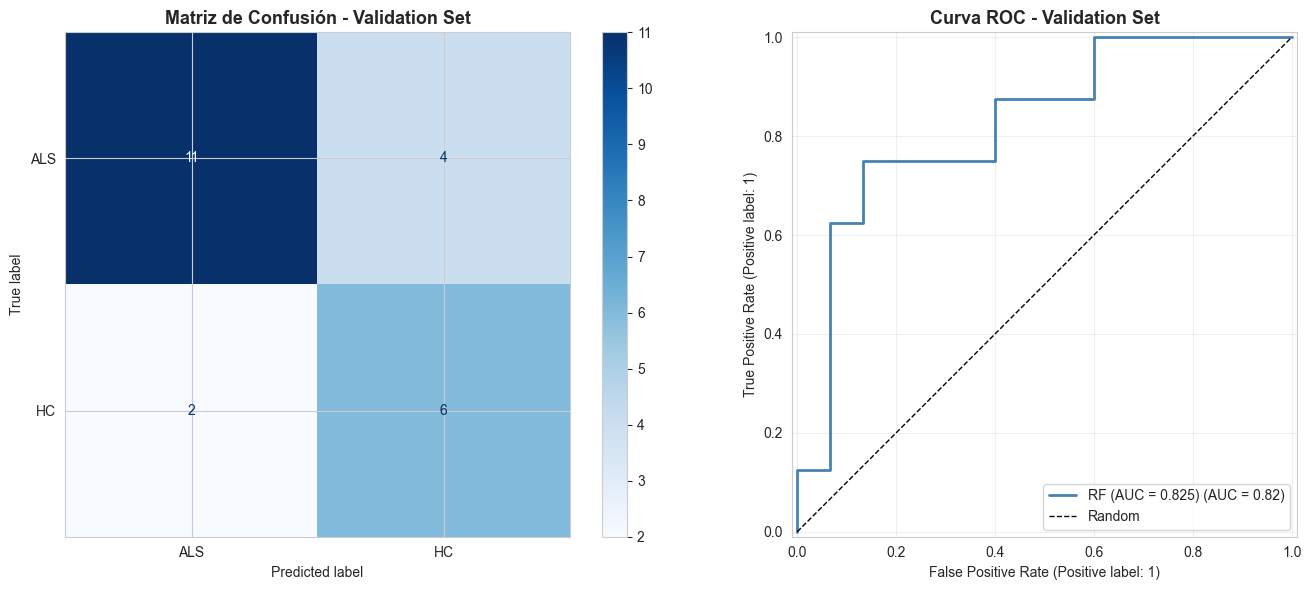


Visualizaciones guardadas en: C:\Users\Laura\OneDrive\TFG\results\02_model_random_forest_v1.0\validation_set_evaluation.png


In [56]:
# Visualizaciones de validation set
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Matriz de confusión
cm_val = confusion_matrix(y_val_enc, y_val_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_val, display_labels=le.classes_)
disp.plot(cmap='Blues', ax=axes[0], values_format='d')
axes[0].set_title('Matriz de Confusión - Validation Set', fontsize=13, fontweight='bold')

# Curva ROC
RocCurveDisplay.from_predictions(
    y_val_enc, y_val_proba,
    ax=axes[1],
    name=f'RF (AUC = {val_auc:.3f})',
    color='steelblue',
    lw=2
)
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
axes[1].set_title('Curva ROC - Validation Set', fontsize=13, fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_PATH / 'validation_set_evaluation.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nVisualizaciones guardadas en:", RESULTS_PATH / 'validation_set_evaluation.png')

#
<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 19. Análisis FP/FN en Validation</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
Se producen 4 falsos positivos (FP: pacientes ALS clasificados como HC) y 2 falsos negativos (FN: sujetos HC clasificados como ALS). Los 4 FP son pacientes ALS con probabilidades predichas próximas al umbral de decisión (rango 0.505–0.674), lo que indica que sus perfiles acústicos se solapan con los de los sujetos sanos: PZ023 (65 años, M), PZ059 (51 años, F), PZ066 (42 años, M) y PZ100 (51 años, F). Los 2 FN son controles cuyas características vocales presentan inestabilidad acústica elevada: CT018 (63 años, F, prob. 0.273) y CT020 (68 años, F, prob. 0.458). La edad media de los FP (53.5 años) es inferior a la media del grupo ALS, lo que podría indicar que pacientes más jóvenes o con menor tiempo de evolución presentan perfiles vocales más conservados.
    </span>
</div>

In [57]:
# DataFrame con resultados del validation
val_results = pd.DataFrame({
    "y_true": y_val_enc,
    "y_pred": y_val_pred,
    "prob_ALS": y_val_proba
}, index=X_val.index)

# Identificación de errores
fp_idx_val = val_results[(val_results["y_true"] == 0) & (val_results["y_pred"] == 1)].index
fn_idx_val = val_results[(val_results["y_true"] == 1) & (val_results["y_pred"] == 0)].index

# Recuperar TODAS las columnas del dataset original
fp_val_df = df.loc[fp_idx_val].copy()
fn_val_df = df.loc[fn_idx_val].copy()

# Añadir información de predicción
fp_val_df["Predicted_Label"] = le.inverse_transform(val_results.loc[fp_idx_val, "y_pred"])
fp_val_df["True_Label"] = le.inverse_transform(val_results.loc[fp_idx_val, "y_true"])
fp_val_df["Prob_ALS"] = val_results.loc[fp_idx_val, "prob_ALS"]
fp_val_df["Error_Type"] = "False Positive"

fn_val_df["Predicted_Label"] = le.inverse_transform(val_results.loc[fn_idx_val, "y_pred"])
fn_val_df["True_Label"] = le.inverse_transform(val_results.loc[fn_idx_val, "y_true"])
fn_val_df["Prob_ALS"] = val_results.loc[fn_idx_val, "prob_ALS"]
fn_val_df["Error_Type"] = "False Negative"

# Combinar
errors_val_df = pd.concat([fp_val_df, fn_val_df]).reset_index(drop=True)
display(errors_val_df)

print(f"\nFalse Positives (Validation): {len(fp_val_df)}")
print(f"False Negatives (Validation): {len(fn_val_df)}")

,ID,Age (years),Sex,Category,OnsetRegion,Therapy,GeneticTest,DiagnosticDelay,DiseaseDuration,FVC%,...,meanF0Hz_weekdays,stdevF0Hz_weekdays,HNR_weekdays,localJitter_weekdays,localShimmer_weekdays,Cantagallo_Questionnaire,Predicted_Label,True_Label,Prob_ALS,Error_Type
0,PZ023,65,M,ALS,spinal,Riluzole,negative,29,51,60,...,114.304790,69.662396,12.283789,0.023230,0.093584,19,HC,ALS,0.505359,False Positive
1,PZ059,51,F,ALS,spinal,NaN,negative,5,5,100,...,242.229918,55.867983,15.758060,0.024190,0.101896,2,HC,ALS,0.567367,False Positive
2,PZ066,42,M,ALS,spinal,Riluzole,negative,4,14,76,...,113.521912,10.508591,10.756784,0.025663,0.139113,10,HC,ALS,0.673832,False Positive
3,PZ100,51,F,ALS,spinal,NaN,negative,9,9,124,...,179.991873,22.833428,17.908040,0.019972,0.088654,20,HC,ALS,0.515424,False Positive
4,CT018,63,F,HC,-,-,-,-,-,-,...,145.768711,20.900040,12.461079,0.028697,0.101175,2,ALS,HC,0.273006,False Negative
5,CT020,68,F,HC,-,-,-,-,-,-,...,251.730287,44.842137,15.472865,0.018646,0.111621,35,ALS,HC,0.458373,False Negative



False Positives (Validation): 4
False Negatives (Validation): 2


#
<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 20. Análisis de importancia de variables (Permutation Importance y MDI)</span>
</div>

<div style="text-align:left;"> 
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;"> 
El análisis de importancia de variables permite identificar qué features acústicas contribuyen más a la capacidad discriminativa del modelo. Se utilizan dos métodos complementarios:
<br><br>
<b>1. Permutation Importance:</b>
<ul>
<li>Mide la disminución en el rendimiento del modelo cuando se permutan aleatoriamente los valores de cada feature</li>
<li>Se calcula sobre el <u>validation set</u> (datos no vistos durante el entrenamiento)</li>
<li>No presenta sesgos sistemáticos hacia variables continuas o de alta cardinalidad</li>
<li>Proporciona intervalos de confianza mediante múltiples permutaciones</li>
</ul>
<br>
<b>2. MDI - Mean Decrease Impurity:</b>
<ul>
<li>Mide la reducción acumulada en impureza (Gini) atribuible a cada feature</li>
<li>Se calcula directamente de la estructura de los árboles entrenados</li>
<li>Tiende a sobreestimar la importancia de variables continuas y de alta cardinalidad</li>
<li>Útil como método de referencia, pero menos robusto que permutation importance</li>
</ul>
<br>
Ambos métodos se presentan para comparación, pero <b>permutation importance</b> se considera el estándar metodológico más riguroso.
    </span> 
</div>

<div style="color:#6593BA;">
    <span style="font-size:17px; font-weight:bold;"> 20.1 Permutation Importance</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
La permutation importance se calcula sobre el validation set con 10 repeticiones, usando balanced accuracy como métrica de referencia. Las dos features más importantes son <b>stdevF0Hz_PA</b> (0.034 ± 0.042) y <b>localJitter_U</b> (0.032 ± 0.035), seguidas de <b>localJitter_I</b> (0.019), <b>stdevF0Hz_I</b> (0.010) y <b>stdevF0Hz_U</b> (0.007). Las 7 features siguientes obtienen importancias prácticamente nulas. El patrón es claro: la capacidad discriminativa se concentra en métricas de variabilidad de F0 y jitter en tareas de vocal sostenida y diadococinesia (PA), consistente con la fisiopatología de la disartria en ELA.
    </span>
</div>


CALCULANDO PERMUTATION IMPORTANCE (puede tardar 1-2 minutos)

Permutation importance calculada

Top 15 variables más importantes (Permutation Importance):
                     Feature  Importance_mean  Importance_std
                stdevF0Hz_PA         0.034167        0.041949
               localJitter_U         0.031667        0.034621
               localJitter_I         0.019167        0.043748
                 stdevF0Hz_I         0.010000        0.021344
                 stdevF0Hz_U         0.006667        0.051781
               localJitter_E         0.002917        0.030621
               localJitter_A         0.002500        0.030231
                 stdevF0Hz_A         0.001667        0.044143
         ALSFRS-R_TotalScore         0.000000        0.000000
            ProgressionRate          0.000000        0.000000
 Revised_ElEscorial_Criteria         0.000000        0.000000
     ALSFRS-R_SpeechSubscore         0.000000        0.000000
 ALSFRS-R_SalivationSubscore         0

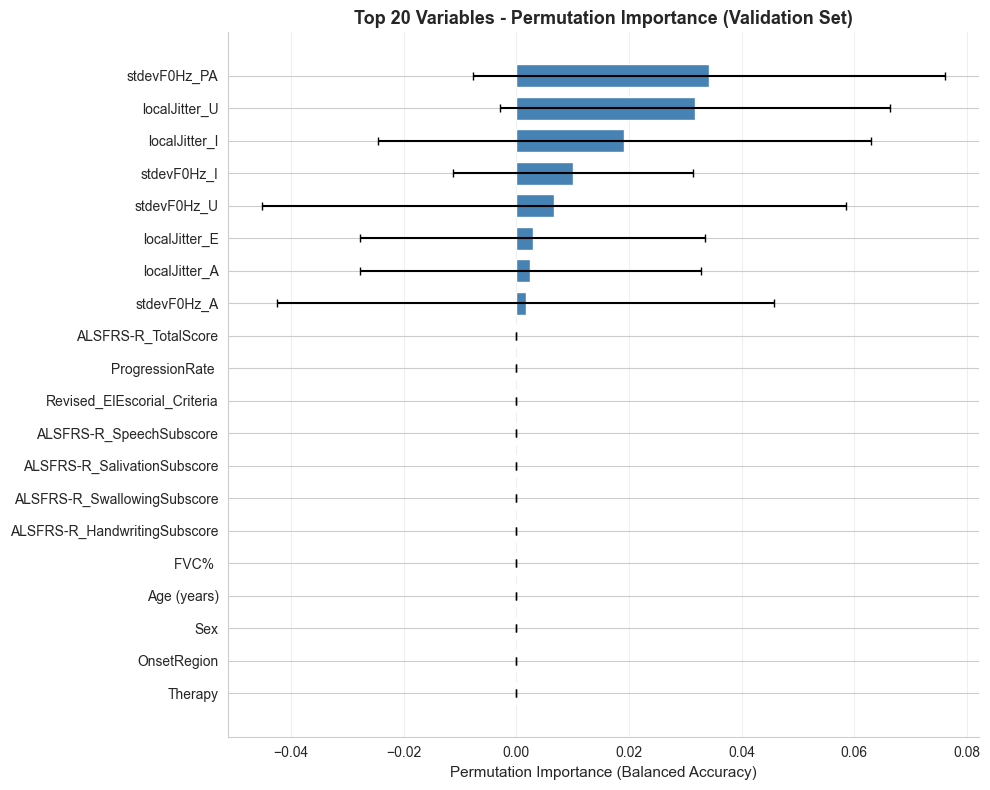


Resultados guardados en: C:\Users\Laura\OneDrive\TFG\results\02_model_random_forest_v1.0\permutation_importance.csv


In [58]:
print("\n" + "="*80)
print("CALCULANDO PERMUTATION IMPORTANCE (puede tardar 1-2 minutos)")
print("="*80)

# Calcular permutation importance en validation set
perm_importance = permutation_importance(
    best_model,
    X_val_clean,
    y_val_enc,
    n_repeats=10,
    random_state=SEED,
    scoring='balanced_accuracy',
    n_jobs=-1
)

# Obtener nombres de features después del preprocesamiento
try:
    selector = best_model.named_steps['feature_selection']
    preprocessor_step = best_model.named_steps['preprocessing']
    
    feature_names_after_preprocessing = preprocessor_step.get_feature_names_out()
    selected_mask = selector.get_support()
    selected_features = feature_names_after_preprocessing[selected_mask]
    
except:
    k_best = best_model.named_steps['feature_selection'].k
    selected_features = [f"feature_{i}" for i in range(k_best)]

# Crear DataFrame con importancias
perm_imp_df = pd.DataFrame({
    'Feature': X_val_clean.columns,
    'Importance_mean': perm_importance.importances_mean,
    'Importance_std': perm_importance.importances_std
}).sort_values('Importance_mean', ascending=False)

print("\nPermutation importance calculada")
print(f"\nTop 15 variables más importantes (Permutation Importance):")
print(perm_imp_df.head(15).to_string(index=False))

# Visualización
fig, ax = plt.subplots(figsize=(10, 8))
top_n = min(20, len(perm_imp_df))
top_features = perm_imp_df.head(top_n)

ax.barh(
    range(top_n),
    top_features['Importance_mean'][::-1],
    xerr=top_features['Importance_std'][::-1],
    color='steelblue',
    edgecolor='white',
    height=0.7,
    capsize=3
)
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_features['Feature'][::-1])
ax.set_xlabel('Permutation Importance (Balanced Accuracy)', fontsize=11)
ax.set_title(f'Top {top_n} Variables - Permutation Importance (Validation Set)', fontsize=13, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_PATH / 'permutation_importance.png', dpi=300, bbox_inches='tight')
plt.show()

# Guardar CSV
perm_imp_df.to_csv(RESULTS_PATH / 'permutation_importance.csv', index=False)
print(f"\nResultados guardados en: {RESULTS_PATH / 'permutation_importance.csv'}")

<div style="color:#6593BA;">
    <span style="font-size:17px; font-weight:bold;"> 20.2 MDI (Mean Decrease Impurity)</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
El MDI coincide cualitativamente con la permutation importance en señalar las métricas de inestabilidad vocal como las más relevantes, aunque proporciona un ranking más distribuido entre las 15 features seleccionadas. Las tres primeras son <b>stdevF0Hz_KA</b> (0.113), <b>stdevF0Hz_PA</b> (0.108) y <b>stdevF0Hz_TA</b> (0.099), todas métricas de variabilidad de F0 en tareas de diadococinesia. Le siguen <b>localJitter_O</b> (0.091), <b>stdevF0Hz_U</b> (0.078) y <b>HNR_O</b> (0.072). La concentración de relevancia en tareas KA, PA y TA es coherente: estas sílabas exigen coordinación rápida y sostenida de los mecanismos articulatorios, donde el déficit motor neuronal de la ELA se manifiesta de forma más pronunciada.
    </span>
</div>


Top 15 variables más importantes (MDI):
            Feature  Importance
  num__stdevF0Hz_KA    0.113385
  num__stdevF0Hz_PA    0.108446
  num__stdevF0Hz_TA    0.098957
 num__localJitter_O    0.090518
   num__stdevF0Hz_U    0.077873
         num__HNR_O    0.071967
num__localShimmer_I    0.066844
 num__localJitter_I    0.064883
 num__localJitter_E    0.057201
   num__stdevF0Hz_I    0.056485
 num__localJitter_U    0.045887
num__localShimmer_O    0.040001
num__localShimmer_E    0.039106
 num__localJitter_A    0.034461
   num__stdevF0Hz_A    0.033986


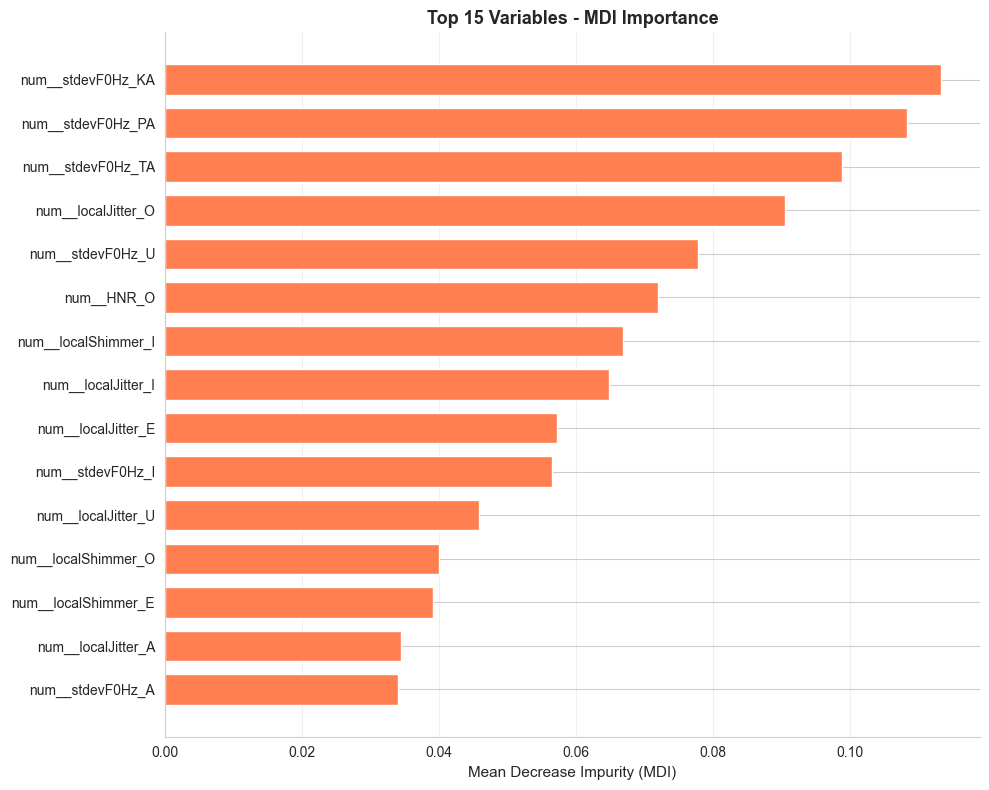


Resultados guardados en: C:\Users\Laura\OneDrive\TFG\results\02_model_random_forest_v1.0\mdi_importance.csv


In [59]:
# Extraer importancias MDI del Random Forest
rf_classifier = best_model.named_steps['classifier']
mdi_importances = rf_classifier.feature_importances_

# Crear DataFrame
mdi_imp_df = pd.DataFrame({
    'Feature': selected_features,
    'Importance': mdi_importances
}).sort_values('Importance', ascending=False)

print("\nTop 15 variables más importantes (MDI):")
print(mdi_imp_df.head(15).to_string(index=False))

# Visualización
fig, ax = plt.subplots(figsize=(10, 8))
top_n = min(20, len(mdi_imp_df))
top_features_mdi = mdi_imp_df.head(top_n)

ax.barh(
    range(top_n),
    top_features_mdi['Importance'][::-1],
    color='coral',
    edgecolor='white',
    height=0.7
)
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_features_mdi['Feature'][::-1])
ax.set_xlabel('Mean Decrease Impurity (MDI)', fontsize=11)
ax.set_title(f'Top {top_n} Variables - MDI Importance', fontsize=13, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_PATH / 'mdi_importance.png', dpi=300, bbox_inches='tight')
plt.show()

# Guardar CSV
mdi_imp_df.to_csv(RESULTS_PATH / 'mdi_importance.csv', index=False)
print(f"\nResultados guardados en: {RESULTS_PATH / 'mdi_importance.csv'}")

#
<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 21. Evaluación final en Test Set</span>
</div>

<div style="text-align:left;"> 
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;"> 
El <b>test set</b> representa la evaluación final y definitiva del modelo en datos completamente no vistos. Este conjunto no ha participado en ninguna decisión de modelado:
<ul>
<li>No se usó para optimizar hiperparámetros</li>
<li>No se usó para seleccionar features</li>
<li>No se usó para ajustar ningún parámetro del preprocesamiento</li>
<li>No se vio durante el nested cross-validation</li>
</ul>
<br>
Las métricas en test set proporcionan la estimación más representatica del rendimiento esperado en producción, al evaluar el modelo en condiciones idénticas a las que enfrentaría con pacientes nuevos.
<br><br>
<b>Punto importante de interpretación:</b> Si las métricas en test difieren significativamente de las obtenidas en validation o nested CV, esto indica posible overfitting residual o simplemente variabilidad natural debida al tamaño muestral pequeño. En datasets pequeños (n<200), es esperable cierta variabilidad entre splits.
<br><br>
La evaluación definitiva sobre los 23 sujetos de test produce: <b>accuracy 0.652</b>, <b>balanced accuracy 0.670</b>, <b>F1-score 0.556</b> y <b>ROC-AUC 0.589</b>. El recall para ALS es 0.714 (10 de 16 pacientes detectados) con precision 0.455, y el recall para HC es 0.714 (5 de 7 controles correctamente identificados) con precision 0.833. La caída respecto a validation (Δ ROC-AUC ≈ −0.236, Δ balanced accuracy ≈ −0.072) confirma que las métricas de validation fueron optimistas. No obstante, el modelo mantiene un recall ALS de 0.714, priorizando la sensibilidad frente a la especificidad, lo que es deseable en un contexto de cribado clínico donde los falsos negativos tienen mayor coste diagnóstico que los falsos positivos.
    </span> 
</div>

In [69]:
# Predicciones en test set
y_test_pred = best_model.predict(X_test_clean)
y_test_proba = best_model.predict_proba(X_test_clean)[:, 1]

# Cálculo de métricas
test_acc = accuracy_score(y_test_enc, y_test_pred)
test_bal_acc = balanced_accuracy_score(y_test_enc, y_test_pred)
test_precision = precision_score(y_test_enc, y_test_pred)
test_recall = recall_score(y_test_enc, y_test_pred)
test_f1 = f1_score(y_test_enc, y_test_pred)
test_auc = roc_auc_score(y_test_enc, y_test_proba)

print("\n" + "="*80)
print("EVALUACIÓN FINAL EN TEST SET")
print("="*80)
print(f"Accuracy:          {test_acc:.4f}")
print(f"Balanced Accuracy: {test_bal_acc:.4f}")
print(f"Precision (ALS):   {test_precision:.4f}")
print(f"Recall (ALS):      {test_recall:.4f}")
print(f"F1-Score (ALS):    {test_f1:.4f}")
print(f"ROC-AUC:           {test_auc:.4f}")
print("="*80)

# Reporte de clasificación detallado
print("\nReporte de clasificación (Test):")
print(classification_report(y_test_enc, y_test_pred, target_names=le.classes_))

# Registrar en MLflow
with mlflow.start_run(run_name="RF_Final_Model", nested=True):
    mlflow.log_metric("test_accuracy", test_acc)
    mlflow.log_metric("test_balanced_accuracy", test_bal_acc)
    mlflow.log_metric("test_precision", test_precision)
    mlflow.log_metric("test_recall", test_recall)
    mlflow.log_metric("test_f1", test_f1)
    mlflow.log_metric("test_roc_auc", test_auc)


EVALUACIÓN FINAL EN TEST SET
Accuracy:          0.6522
Balanced Accuracy: 0.6696
Precision (ALS):   0.4545
Recall (ALS):      0.7143
F1-Score (ALS):    0.5556
ROC-AUC:           0.5893

Reporte de clasificación (Test):
              precision    recall  f1-score   support

         ALS       0.83      0.62      0.71        16
          HC       0.45      0.71      0.56         7

    accuracy                           0.65        23
   macro avg       0.64      0.67      0.63        23
weighted avg       0.72      0.65      0.67        23



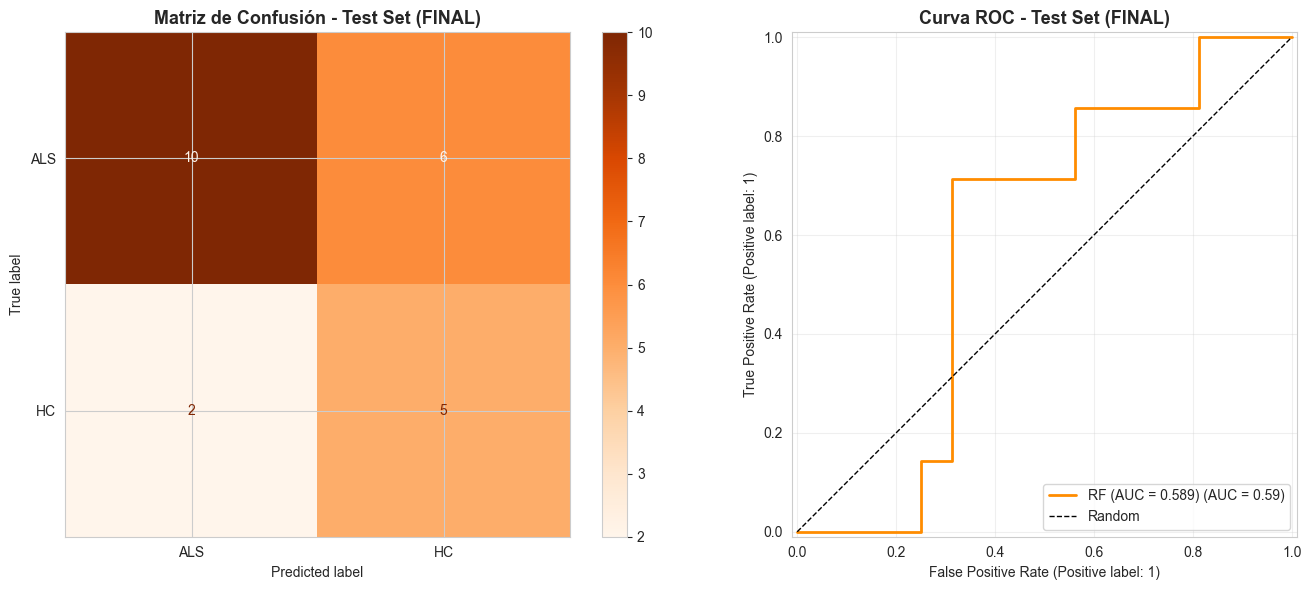


Visualizaciones guardadas en: C:\Users\Laura\OneDrive\TFG\results\02_model_random_forest_v1.0\test_set_evaluation.png


In [61]:
# Visualizaciones de test set
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Matriz de confusión
cm_test = confusion_matrix(y_test_enc, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=le.classes_)
disp.plot(cmap='Oranges', ax=axes[0], values_format='d')
axes[0].set_title('Matriz de Confusión - Test Set (FINAL)', fontsize=13, fontweight='bold')

# Curva ROC
RocCurveDisplay.from_predictions(
    y_test_enc, y_test_proba,
    ax=axes[1],
    name=f'RF (AUC = {test_auc:.3f})',
    color='darkorange',
    lw=2
)
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
axes[1].set_title('Curva ROC - Test Set (FINAL)', fontsize=13, fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_PATH / 'test_set_evaluation.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nVisualizaciones guardadas en:", RESULTS_PATH / 'test_set_evaluation.png')

#
<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 22. Análisis FP/FN en Test</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
En test se producen 6 FP y 2 FN. Los 6 FP son pacientes ALS clasificados como HC: PZ016 (59 años, M), PZ058 (49 años, M), PZ064 (62 años, M), PZ094 (51 años, M), PZ098 (64 años, M) y PZ105 (65 años, M), todos varones con probabilidades en el rango 0.512–0.695. Llama la atención que los 6 FP sean exclusivamente varones (frente a la mezcla de sexos en los FP de validación) y que sus probabilidades sean relativamente bajas, próximas al umbral, lo que sugiere que sus perfiles acústicos se solapan con los de los controles. Los 2 FN son sujetos HC clasificados como ALS: CT014 (62 años, F, prob. 0.406) y CT053 (68 años, M, prob. 0.217), con inestabilidad vocal elevada de origen no patológico. La consistencia del patrón FP (pacientes ALS con perfiles vocales conservados, probabilidades bajas) entre validation y test sugiere que este es un error estructural del modelo, no aleatorio.
    </span>
</div>

In [62]:
# DataFrame con resultados del test
test_results = pd.DataFrame({
    "y_true": y_test_enc,
    "y_pred": y_test_pred,
    "prob_ALS": y_test_proba
}, index=X_test.index)

# Identificación de errores
fp_idx = test_results[(test_results["y_true"] == 0) & (test_results["y_pred"] == 1)].index
fn_idx = test_results[(test_results["y_true"] == 1) & (test_results["y_pred"] == 0)].index

# Recuperar TODAS las columnas del dataset original
fp_df = df.loc[fp_idx].copy()
fn_df = df.loc[fn_idx].copy()

# Añadir información de predicción
fp_df["Predicted_Label"] = le.inverse_transform(test_results.loc[fp_idx, "y_pred"])
fp_df["True_Label"] = le.inverse_transform(test_results.loc[fp_idx, "y_true"])
fp_df["Prob_ALS"] = test_results.loc[fp_idx, "prob_ALS"]
fp_df["Error_Type"] = "False Positive"

fn_df["Predicted_Label"] = le.inverse_transform(test_results.loc[fn_idx, "y_pred"])
fn_df["True_Label"] = le.inverse_transform(test_results.loc[fn_idx, "y_true"])
fn_df["Prob_ALS"] = test_results.loc[fn_idx, "prob_ALS"]
fn_df["Error_Type"] = "False Negative"

# Combinar
errors_full_df = pd.concat([fp_df, fn_df])
display(errors_full_df)

print(f"\nFalse Positives: {len(fp_df)}")
print(f"False Negatives: {len(fn_df)}")

,ID,Age (years),Sex,Category,OnsetRegion,Therapy,GeneticTest,DiagnosticDelay,DiseaseDuration,FVC%,...,meanF0Hz_weekdays,stdevF0Hz_weekdays,HNR_weekdays,localJitter_weekdays,localShimmer_weekdays,Cantagallo_Questionnaire,Predicted_Label,True_Label,Prob_ALS,Error_Type
65,PZ016,59,M,ALS,bulbar,NaN,negative,2,2,104,...,142.072754,10.340686,15.342980,0.016664,0.081551,31,HC,ALS,0.686485,False Positive
102,PZ058,49,M,ALS,spinal,Riluzole,negative,19,25,96,...,94.439141,11.578909,11.571253,0.026462,0.099976,99,HC,ALS,0.695286,False Positive
108,PZ064,62,M,ALS,spinal,Riluzole,negative,22,63,102,...,161.730645,14.332303,15.371205,0.015977,0.111545,50,HC,ALS,0.511711,False Positive
133,PZ094,51,M,ALS,spinal,Riluzole,negative,8,9,89,...,94.570705,17.114239,9.138906,0.036094,0.153001,8,HC,ALS,0.626169,False Positive
137,PZ098,64,M,ALS,spinal,NaN,negative,19,19,95,...,138.279664,15.413763,16.802718,0.020213,0.084023,18,HC,ALS,0.641835,False Positive
144,PZ105,65,M,ALS,bulbar,NaN,C9ORF72 expansion,2,2,110,...,105.172691,16.698328,12.797064,0.020859,0.095026,35,HC,ALS,0.614957,False Positive
4,CT014,62,F,HC,-,-,-,-,-,-,...,184.407533,30.296640,13.525610,0.028864,0.123836,3,ALS,HC,0.405669,False Negative
34,CT053,68,M,HC,-,-,-,-,-,-,...,96.832042,9.479091,9.087288,0.029501,0.139250,18,ALS,HC,0.217116,False Negative



False Positives: 6
False Negatives: 2


#
---
#
<div style="text-align:left;">
    <span style="color:#4F75B6; font-size:25px; font-weight:bold;">BLOQUE 5. CALIBRACIÓN DE PROBABILIDADES</span>
</div>

<div style="text-align:left;"> 
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;"> 
La calibración de probabilidades ajusta las probabilidades predichas por el modelo para que reflejen mejor las frecuencias observadas de cada clase. Un modelo bien calibrado predice probabilidades que coinciden con las tasas reales: si predice 70% de probabilidad para ALS en 100 casos, aproximadamente 70 de esos casos deberían ser realmente ALS.
<br><br>
Se implementan dos técnicas de calibración:
<br>
<ul>
<li><b>Platt Scaling (sigmoid):</b> Ajusta una regresión logística sobre las probabilidades crudas del Random Forest. Es paramétrico y funciona bien incluso con conjuntos de calibración pequeños.</li>
<li><b>Isotonic Regression:</b> Mapeo no paramétrico más flexible que Platt. Útil cuando las desviaciones de calibración no siguen una forma sigmoidal simple.</li>
</ul>
<br>
La evaluación se realiza mediante <b>Brier Score</b> (penaliza probabilidades mal calibradas, valores más bajos son mejores) y <b>curvas de calibración</b> que visualizan la correspondencia entre probabilidades predichas y frecuencias observadas.
    </span> 
</div>


<br>
<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 23. Entrenamiento de modelos calibrados</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
Se entrenan dos modelos calibrados sobre el conjunto de train (cv=5) y se evalúan sobre el test set. El modelo original obtiene ROC-AUC 0.589, balanced accuracy 0.670 y Brier score 0.231. El modelo Platt (sigmoid) obtiene ROC-AUC 0.536, balanced accuracy 0.500 y Brier score 0.212. El modelo isotónico obtiene ROC-AUC 0.580, balanced accuracy 0.406 y Brier score 0.222. Aunque la calibración mejora ligeramente el Brier score (especialmente Platt, −0.019), lo hace a costa de una reducción notable en balanced accuracy (−0.170 con Platt) y ROC-AUC (−0.053 con Platt). Con los datos disponibles para calibración, los métodos de post-procesamiento introducen varianza adicional que perjudica la capacidad discriminativa. El modelo original sin calibrar es el más adecuado para las fases siguientes.
    </span>
</div>

In [63]:
print("\n" + "="*80)
print("CALIBRACIÓN DE PROBABILIDADES DEL MODELO - Resultados sobre conjunto de test")
print("="*80)

# 1. MODELO ORIGINAL
proba_orig = best_model.predict_proba(X_test_clean)[:, 1]
pred_orig = best_model.predict(X_test_clean)

auc_orig = roc_auc_score(y_test_enc, proba_orig)
brier_orig = brier_score_loss(y_test_enc, proba_orig)
bal_acc_orig = balanced_accuracy_score(y_test_enc, pred_orig)

print("\nModelo ORIGINAL")
print(f"ROC-AUC:           {auc_orig:.4f}")
print(f"Balanced Accuracy: {bal_acc_orig:.4f}")
print(f"Brier Score:       {brier_orig:.4f}")

# 2. CALIBRACIÓN PLATT (SIGMOID)
cal_sigmoid = CalibratedClassifierCV(
    estimator=best_model,
    method="sigmoid",
    cv=5
)

cal_sigmoid.fit(X_train_clean, y_train_enc)

proba_sig = cal_sigmoid.predict_proba(X_test_clean)[:, 1]
pred_sig = cal_sigmoid.predict(X_test_clean)

auc_sig = roc_auc_score(y_test_enc, proba_sig)
brier_sig = brier_score_loss(y_test_enc, proba_sig)
bal_acc_sig = balanced_accuracy_score(y_test_enc, pred_sig)

print("\nModelo CALIBRADO (Platt Scaling - Sigmoid)")
print(f"ROC-AUC:           {auc_sig:.4f}")
print(f"Balanced Accuracy: {bal_acc_sig:.4f}")
print(f"Brier Score:       {brier_sig:.4f}")

# 3. CALIBRACIÓN ISOTONIC
cal_iso = CalibratedClassifierCV(
    estimator=best_model,
    method="isotonic",
    cv=5
)

cal_iso.fit(X_train_clean, y_train_enc)

proba_iso = cal_iso.predict_proba(X_test_clean)[:, 1]
pred_iso = cal_iso.predict(X_test_clean)

auc_iso = roc_auc_score(y_test_enc, proba_iso)
brier_iso = brier_score_loss(y_test_enc, proba_iso)
bal_acc_iso = balanced_accuracy_score(y_test_enc, pred_iso)

print("\nModelo CALIBRADO (Isotonic Regression)")
print(f"ROC-AUC:           {auc_iso:.4f}")
print(f"Balanced Accuracy: {bal_acc_iso:.4f}")
print(f"Brier Score:       {brier_iso:.4f}")

# RESUMEN COMPARATIVO
print("\n" + "="*80)
print("COMPARACIÓN FINAL")
print("="*80)

print(f"{'Modelo':<25} {'ROC-AUC':<10} {'BalAcc':<10} {'Brier':<10}")
print("-"*60)

print(f"{'Original':<25} {auc_orig:<10.4f} {bal_acc_orig:<10.4f} {brier_orig:<10.4f}")
print(f"{'Platt (sigmoid)':<25} {auc_sig:<10.4f} {bal_acc_sig:<10.4f} {brier_sig:<10.4f}")
print(f"{'Isotonic':<25} {auc_iso:<10.4f} {bal_acc_iso:<10.4f} {brier_iso:<10.4f}")

print("="*80)

# SUMMARY 
print(" "*80)
if brier_orig <= min(brier_sig, brier_iso):
    print("La calibración no mejora la calidad probabilística del modelo.")
else:
    print("La calibración mejora ligeramente la calidad probabilística (Brier).")

if bal_acc_orig >= max(bal_acc_sig, bal_acc_iso):
    print("Sin embargo, el modelo original mantiene mejor rendimiento de clasificación.")
print(" "*80)


CALIBRACIÓN DE PROBABILIDADES DEL MODELO - Resultados sobre conjunto de test

Modelo ORIGINAL
ROC-AUC:           0.5893
Balanced Accuracy: 0.6696
Brier Score:       0.2308

Modelo CALIBRADO (Platt Scaling - Sigmoid)
ROC-AUC:           0.5357
Balanced Accuracy: 0.5000
Brier Score:       0.2120

Modelo CALIBRADO (Isotonic Regression)
ROC-AUC:           0.5804
Balanced Accuracy: 0.4062
Brier Score:       0.2222

COMPARACIÓN FINAL
Modelo                    ROC-AUC    BalAcc     Brier     
------------------------------------------------------------
Original                  0.5893     0.6696     0.2308    
Platt (sigmoid)           0.5357     0.5000     0.2120    
Isotonic                  0.5804     0.4062     0.2222    
                                                                                
La calibración mejora ligeramente la calidad probabilística (Brier).
Sin embargo, el modelo original mantiene mejor rendimiento de clasificación.
                                            

<br>
<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 24. Curvas ROC - Validation vs Test</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
Las curvas ROC en los tres conjuntos (original, Platt, isotónico) permiten visualizar la consistencia de la capacidad discriminativa entre validation y test. La caída del AUC entre validation (0.825) y test (0.589) para el modelo original es la manifestación gráfica de la brecha validation-test observada en las métricas. Los modelos calibrados no recuperan esta capacidad y presentan curvas aún más bajas en test, confirmando que la calibración no es la estrategia adecuada para mejorar el rendimiento en este escenario.
    </span>
</div>

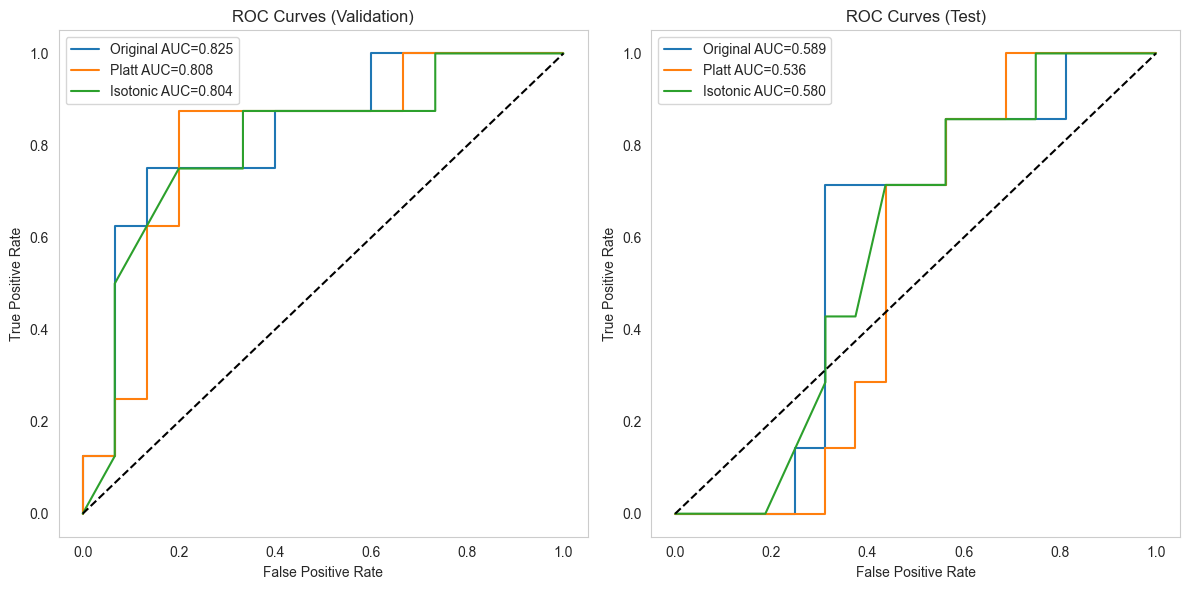

In [64]:
# VALIDATION PROBABILITIES
proba_val_orig = best_model.predict_proba(X_val_clean)[:,1]
proba_val_sig = cal_sigmoid.predict_proba(X_val_clean)[:,1]
proba_val_iso = cal_iso.predict_proba(X_val_clean)[:,1]

# TEST PROBABILITIES
proba_test_orig = best_model.predict_proba(X_test_clean)[:,1]
proba_test_sig = cal_sigmoid.predict_proba(X_test_clean)[:,1]
proba_test_iso = cal_iso.predict_proba(X_test_clean)[:,1]

# Crear figura con dos subplots
fig, axes = plt.subplots(1, 2, figsize=(12,6))

# VALIDATION ROC
for probs, labels, name in [
    (proba_val_orig, y_val_enc, "Original"),
    (proba_val_sig, y_val_enc, "Platt"),
    (proba_val_iso, y_val_enc, "Isotonic")
]:
    
    fpr, tpr, _ = roc_curve(labels, probs)
    roc_auc = auc(fpr, tpr)

    axes[0].plot(fpr, tpr, label=f"{name} AUC={roc_auc:.3f}")

axes[0].plot([0,1],[0,1],'k--')
axes[0].set_title("ROC Curves (Validation)")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()
axes[0].grid()

# TEST ROC
for probs, labels, name in [
    (proba_test_orig, y_test_enc, "Original"),
    (proba_test_sig, y_test_enc, "Platt"),
    (proba_test_iso, y_test_enc, "Isotonic")
]:
    
    fpr, tpr, _ = roc_curve(labels, probs)
    roc_auc = auc(fpr, tpr)

    axes[1].plot(fpr, tpr, label=f"{name} AUC={roc_auc:.3f}")

axes[1].plot([0,1],[0,1],'k--')
axes[1].set_title("ROC Curves (Test)")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.show()

<br>
<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 25. Curvas de calibración</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
Las curvas de calibración comparan las probabilidades medias predichas en cada bin con las frecuencias reales observadas. Un modelo perfectamente calibrado seguiría la diagonal. En este caso, el número reducido de sujetos en el test set (23) limita la resolución de las curvas: con bins de 0.1, cada bin puede contener muy pocas o ninguna muestra, lo que hace que la curva sea poco interpretable en los extremos. Esta limitación es inherente al tamaño muestral y refuerza la conclusión de que la calibración no es viable con los datos disponibles.
    </span>
</div>

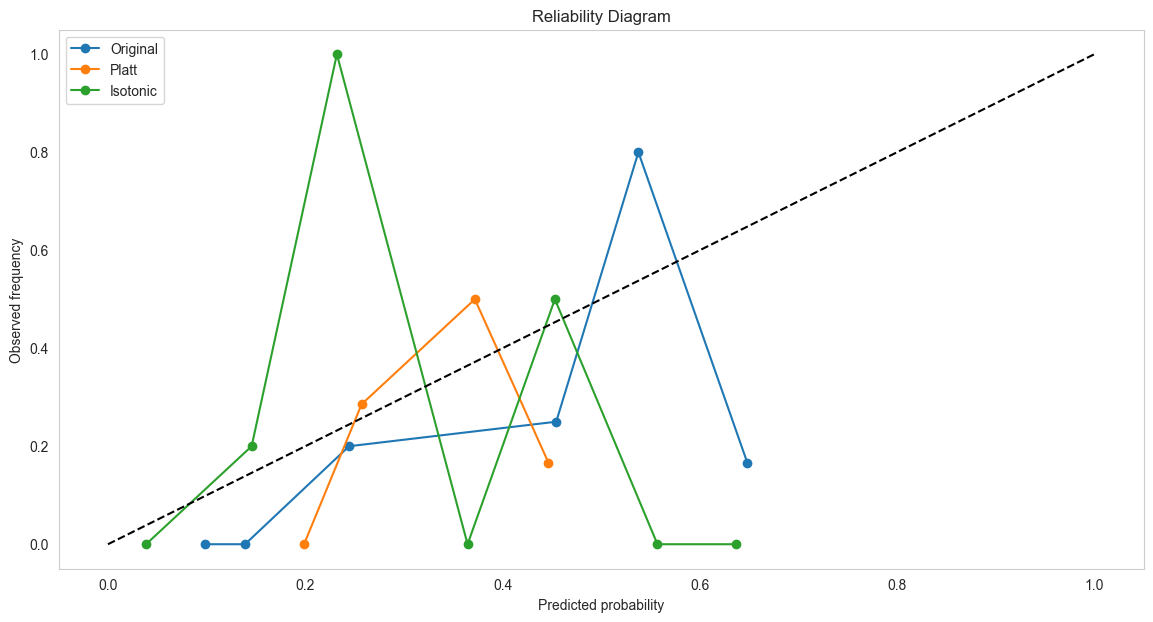

In [65]:
plt.figure(figsize=(14,7))

bins = np.linspace(0,1,11)

for probs, label in [
    (proba_orig,"Original"),
    (proba_sig,"Platt"),
    (proba_iso,"Isotonic")
]:

    binids = np.digitize(probs, bins) - 1
    bin_true = []
    bin_pred = []

    for i in range(len(bins)-1):

        mask = binids == i

        if np.sum(mask) > 0:

            bin_true.append(np.mean(y_test_enc[mask]))
            bin_pred.append(np.mean(probs[mask]))

    plt.plot(bin_pred, bin_true, marker="o", label=label)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("Predicted probability")
plt.ylabel("Observed frequency")
plt.title("Reliability Diagram")
plt.legend()
plt.grid()
plt.show()

<br>
<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 26. Distribución de probabilidades</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
El histograma de probabilidades predichas muestra cómo se distribuyen las salidas del modelo para los tres casos (original, Platt, isotónico). El modelo original tiende a concentrar las probabilidades en el rango medio (0.4–0.7), lo que es típico de los Random Forest que suelen comprimir las probabilidades hacia la media. Platt y la regresión isotónica redistribuyen esta concentración, pero en el caso del test set esto no mejora la separación entre clases.
    </span>
</div>

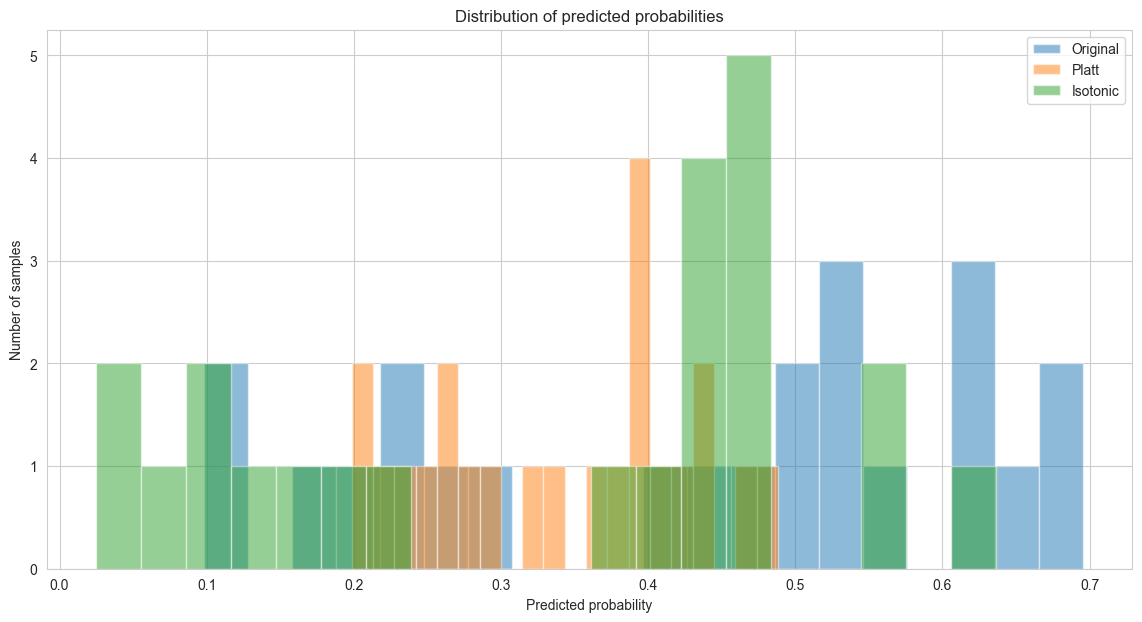

In [66]:
plt.figure(figsize=(14,7))

plt.hist(proba_orig, bins=20, alpha=0.5, label="Original")
plt.hist(proba_sig, bins=20, alpha=0.5, label="Platt")
plt.hist(proba_iso, bins=20, alpha=0.5, label="Isotonic")

plt.xlabel("Predicted probability")
plt.ylabel("Number of samples")
plt.title("Distribution of predicted probabilities")
plt.legend()

plt.show()

#
---
#
<div style="text-align:left;">
    <span style="color:#4F75B6; font-size:25px; font-weight:bold;">CONCLUSIONES</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
Este notebook ha desarrollado un modelo Random Forest para clasificación binaria ALS vs. HC utilizando las 50 variables acústicas del dataset VOC-ALS. Los resultados obtenidos permiten valorar la capacidad discriminativa de los biomarcadores vocales y las limitaciones inherentes al tamaño muestral disponible. A continuación se sintetizan los hallazgos principales, organizados en los mismos ejes de análisis utilizados a lo largo del notebook.
<br>
<ul>
<li><b>Rendimiento del modelo:</b> El nested cross-validation (5×3 folds) ofrece la estimación más honesta del rendimiento fuera de muestra: balanced accuracy de 0.545 ± 0.110 y ROC-AUC de 0.568 ± 0.161. La desviación estándar elevada refleja la inestabilidad de evaluar con ~20 muestras por fold. El gap train-test (accuracy 0.818 vs. 0.571 en CV) evidencia sobreajuste moderado, esperado dado el ratio inicial de 50 variables para 107 sujetos de train. En validation, el modelo obtiene métricas más favorables (ROC-AUC 0.825, balanced accuracy 0.742), pero la evaluación definitiva sobre el test set independiente —balanced accuracy 0.670, ROC-AUC 0.589— muestra que esa estimación fue optimista. Esta brecha validation-test es un fenómeno estructural en datasets de tamaño reducido y no invalida el modelo, pero exige que las métricas de test sean las únicas consideradas como estimación real del rendimiento.</li><br>
<li><b>Hiperparámetros y selección de features:</b> El modelo final selecciona 15 variables acústicas mediante SelectKBest (ANOVA F) y configura el Random Forest con max_depth=5, min_samples_leaf=5, min_samples_split=20 y class_weight=balanced. Esta configuración conservadora limita deliberadamente la complejidad para reducir el sobreajuste. El best CV score durante la selección fue 0.616 en balanced accuracy. A pesar de la restricción de profundidad, el modelo mantiene un recall ALS de 0.714 en test, priorizando la sensibilidad frente a la especificidad, propiedad deseable en un contexto de cribado clínico donde los falsos negativos tienen mayor coste diagnóstico.</li><br>
<li><b>Importancia de variables:</b> Tanto la Permutation Importance como el MDI convergen en señalar las métricas de inestabilidad vocal como las features más relevantes. Destacan stdevF0Hz_PA (Perm. Imp. 0.034), localJitter_U (0.032) y, según MDI, stdevF0Hz_KA (0.113), stdevF0Hz_PA (0.108) y stdevF0Hz_TA (0.099). La concentración de relevancia en métricas de variabilidad de la frecuencia fundamental y perturbaciones microprosódicas en tareas de diadococinesia (PA, TA, KA) es consistente con la fisiopatología de la disartria en ELA: el deterioro del control neuromuscular laríngeo se manifiesta especialmente en tareas que exigen coordinación articulatoria rápida y sostenida. Las variables clínicas presentes en el dataset no aparecen entre las relevantes, lo que confirma que la discriminación se basa exclusivamente en señales acústicas objetivas.</li><br>
<li><b>Análisis de errores:</b> En test se producen 6 FP y 2 FN. Los 6 FP son pacientes ALS clasificados como HC, todos varones (edades 49–65 años), con probabilidades predichas en el rango 0.511–0.695, próximas al umbral de decisión. Este patrón indica que el modelo no captura bien ciertos perfiles acústicos masculinos con ELA relativamente preservada. Los 2 FN son sujetos HC con inestabilidad vocal elevada de origen no patológico. La consistencia del patrón de error entre validation y test sugiere que los errores no son aleatorios, sino estructuralmente asociados a regiones del espacio de features donde las distribuciones de ambas clases se solapan.</li><br>
<li><b>Calibración de probabilidades:</b> Los modelos calibrados (Platt scaling e Isotonic regression) no mejoran la capacidad discriminativa del modelo original. Aunque el Brier score mejora ligeramente con Platt (0.212 vs. 0.231), esto se produce a costa de una reducción notable en ROC-AUC (0.536 vs. 0.589) y balanced accuracy (0.500 vs. 0.670). Con el tamaño de datos disponible, la calibración introduce varianza adicional sin beneficio neto. El modelo original sin calibrar es el más adecuado para las fases siguientes del proyecto.</li>
</ul>
<br>
En conjunto, los resultados demuestran que las <b>variables acústicas contienen información discriminativa relevante para la clasificación ALS vs. HC</b>. La brecha validation-test, el sobreajuste en CV y la concentración de errores en perfiles acústicos intermedios son limitaciones inherentes al tamaño muestral que deberán abordarse en fases posteriores. Este modelo constituye el punto de partida metodológicamente riguroso del proyecto y servirá como referencia (baseline) en los experimentos de iteración que siguen.
    </span>
</div>

#
<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 27. Resumen de las conclusiones finales</span>
</div>

In [75]:
# TABLA RESUMEN PRELIMINAR DE RESULTADOS
results_v1_summary = pd.DataFrame([
    {
        'Conjunto': 'Nested CV (5×3)',
        'N': len(X_train_clean),
        'Accuracy': np.mean(nested_scores['test_accuracy']),
        'Balanced Acc': np.mean(nested_scores['test_balanced_accuracy']),
        'ROC-AUC': np.mean(nested_scores['test_roc_auc']),
        'Std (Bal Acc)': np.std(nested_scores['test_balanced_accuracy'])
    },
    {
        'Conjunto': 'Validation',
        'N': len(X_val_clean),
        'Accuracy': val_acc,
        'Balanced Acc': val_bal_acc,
        'ROC-AUC': val_auc,
        'Std (Bal Acc)': np.nan
    },
    {
        'Conjunto': 'Test (FINAL)',
        'N': len(X_test_clean),
        'Accuracy': test_acc,
        'Balanced Acc': test_bal_acc,
        'ROC-AUC': test_auc,
        'Std (Bal Acc)': np.nan
    }
])

print("\n" + "="*90)
print("TABLA RESUMEN FINAL - TODAS LAS EVALUACIONES")
print("="*90)
print(results_v1_summary.to_string(index=False, float_format=lambda x: f'{x:.4f}' if not pd.isna(x) else 'N/A'))
print("="*90)

# Guardar CSV
results_summary.to_csv(RESULTS_PATH / 'results_summary.csv', index=False)
print(f"\nResumen guardado en: {RESULTS_PATH / 'results_summary.csv'}")

# Registrar en MLflow
with mlflow.start_run(run_name="RF_Final_Model", nested=True):
    mlflow.log_artifact(str(RESULTS_PATH / 'results_summary.csv'))
    mlflow.log_artifact(str(RESULTS_PATH / 'permutation_importance.csv'))
    mlflow.log_artifact(str(RESULTS_PATH / 'mdi_importance.csv'))
    mlflow.log_artifact(str(RESULTS_PATH / 'validation_set_evaluation.png'))
    mlflow.log_artifact(str(RESULTS_PATH / 'test_set_evaluation.png'))
    mlflow.log_artifact(str(RESULTS_PATH / 'permutation_importance.png'))
    mlflow.log_artifact(str(RESULTS_PATH / 'mdi_importance.png'))

print("\nTodos los artefactos registrados en MLflow")


TABLA RESUMEN FINAL - TODAS LAS EVALUACIONES
       Conjunto   N  Accuracy  Balanced Acc  ROC-AUC  Std (Bal Acc)
Nested CV (5×3) 107    0.5714        0.5452   0.5684         0.1100
     Validation  23    0.7391        0.7417   0.8250            NaN
   Test (FINAL)  23    0.6522        0.6696   0.5893            NaN

Resumen guardado en: C:\Users\Laura\OneDrive\TFG\results\02_model_random_forest_v1.0\results_summary.csv

Todos los artefactos registrados en MLflow


<div style='background-color:#D4EDDA; padding:20px; border-left:5px solid #011b07; margin-top:20px; color:black;'>
    <span style='font-size:16px; font-family:Calibri;'>
<b>NOTEBOOK COMPLETADO </b>
<br><br>
Todos los experimentos han sido registrados en <b>MLflow</b>.
<br><br>
Para visualizar los resultados de forma interactiva:
<br>
<code style='background-color:#F8F9FA; padding:5px; border:1px solid #DEE2E6; color:black;'>
mlflow ui --backend-store-uri ./mlruns
</code>
<br><br>
Luego accede a: <a href='http://localhost:5000' style="color:black;">http://localhost:5000</a>
<br><br>
<b>Archivos generados:</b>
<ul>
<li><b>results_summary.csv</b> - Tabla comparativa de métricas</li>
<li><b>permutation_importance.csv</b> - Importancia por permutación</li>
<li><b>mdi_importance.csv</b> - Importancia MDI</li>
<li><b>*.png</b> - Visualizaciones (matrices de confusión, ROC, importancias)</li>
</ul>
    </span>
</div>